# Checkpoint History Error Analysis: v7, v8, v9 vs v5 Benchmark

This notebook compares all autoencoder checkpoint histories in `v7`, `v8`, and `v9` against the benchmark checkpoint in `v5`.

Scope:

- Training/validation history from `Code/results/autoencoder/solubility/{v5,v7,v8,v9}`.
- Test teacher-forced and autoregressive metrics from history JSON files when available, with `Code/results/tables/autoencoder_results.csv` used as the common test-metric source and to fill v5.
- Error analysis is metric-level: loss, accuracy, generalization gap, validation drift, and systematic differences by length split, latent dimension, and teacher-forcing dropout. It does not inspect per-sequence reconstruction errors because those artifacts are not present for these checkpoints.


In [82]:
from pathlib import Path
import json
import math
import re

import matplotlib.pyplot as plt
import pandas as pd

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR
for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (candidate / "Code" / "results" / "tables" / "autoencoder_results.csv").exists():
        PROJECT_ROOT = candidate
        break

RESULTS_ROOT = PROJECT_ROOT / "Code" / "results" / "autoencoder" / "solubility"
RESULTS_TABLE = PROJECT_ROOT / "Code" / "results" / "tables" / "autoencoder_results.csv"
CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints" / "autoencoder" / "solubility"
VERSIONS = ["v5", "v7", "v8", "v9"]
BENCHMARK_VERSION = "v5"

plt.style.use("default")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

print(f"Project root: {PROJECT_ROOT}")
print(f"History root: {RESULTS_ROOT}")
print(f"Results table: {RESULTS_TABLE}")


Project root: /Users/josh/GWU/protein-sequence-augmentation
History root: /Users/josh/GWU/protein-sequence-augmentation/Code/results/autoencoder/solubility
Results table: /Users/josh/GWU/protein-sequence-augmentation/Code/results/tables/autoencoder_results.csv


## Load Histories and Test Metrics

The loader keeps the v5 benchmark and every v7-v9 history. It parses length split, latent dimension, and teacher-forcing dropout from checkpoint names when present, then merges final test metrics from the shared results CSV.


In [83]:
def parse_run_metadata(version, history_path, history):
    stem = history_path.name.removesuffix("_history.json")
    model_name = stem
    if model_name.startswith(f"{version}_"):
        model_name = model_name[len(version) + 1:]

    hp = history.get("hyperparameters", {})
    length_match = re.search(r"length_(\d+)_of_(\d+)", model_name)
    latent_match = re.search(r"latent(\d+)", model_name)
    tfd_match = re.search(r"tfd(\d+)p(\d+)", model_name)

    if tfd_match:
        tfd = float(f"{tfd_match.group(1)}.{tfd_match.group(2)}")
    else:
        tfd = hp.get("teacher_forcing_dropout_rate")

    if length_match:
        length_numerator = int(length_match.group(1))
        length_denominator = int(length_match.group(2))
        length_group = f"{length_numerator}/{length_denominator}"
        length_fraction = length_numerator / length_denominator
    else:
        length_numerator = math.nan
        length_denominator = math.nan
        length_group = "benchmark/full"
        length_fraction = math.nan

    if version == "v5" and model_name == "solubility_ae":
        checkpoint_name = "model_ae_solubility"
    else:
        checkpoint_name = model_name.replace("_history", "")
    checkpoint_path = CHECKPOINT_ROOT / version / f"{checkpoint_name}.pt"

    return {
        "version": version,
        "history_path": str(history_path.relative_to(PROJECT_ROOT)),
        "run_id": f"{version}:{model_name}",
        "model_name": model_name,
        "checkpoint": str(checkpoint_path.relative_to(PROJECT_ROOT)),
        "length_group": length_group,
        "length_numerator": length_numerator,
        "length_denominator": length_denominator,
        "length_fraction": length_fraction,
        "latent_dim": int(latent_match.group(1)) if latent_match else hp.get("latent_dim"),
        "teacher_forcing_dropout": tfd,
        "curriculum_type": history.get("curriculum", {}).get("type"),
        "curriculum_epochs": history.get("curriculum", {}).get("epochs"),
        "num_epochs_requested": hp.get("num_epochs"),
    }


def load_histories(versions):
    runs = []
    for version in versions:
        version_dir = RESULTS_ROOT / version
        for history_path in sorted(version_dir.glob("*history.json")):
            with history_path.open() as f:
                history = json.load(f)
            metadata = parse_run_metadata(version, history_path, history)
            metadata["history"] = history
            runs.append(metadata)
    return runs


runs = load_histories(VERSIONS)
print(f"Loaded {len(runs)} histories")
pd.Series([run["version"] for run in runs]).value_counts().sort_index().rename("history_count")


Loaded 49 histories


v5     1
v7    18
v8    12
v9    18
Name: history_count, dtype: int64

In [84]:
def history_metric(history, split, metric):
    values = history.get(f"{split}_scores", {}).get(metric)
    return values if isinstance(values, list) else []


def flatten_epochs(runs):
    rows = []
    for run in runs:
        history = run["history"]
        epochs = history.get("epochs", [])
        for idx, epoch_record in enumerate(epochs):
            row = {k: v for k, v in run.items() if k != "history"}
            row.update(
                {
                    "epoch": epoch_record.get("epoch", idx + 1),
                    "train_loss": epoch_record.get("train_loss"),
                    "val_loss": epoch_record.get("val_loss"),
                    "train_accuracy": epoch_record.get("train_accuracy"),
                    "val_accuracy": epoch_record.get("val_accuracy"),
                    "train_f1": epoch_record.get("train_f1"),
                    "curriculum_fraction": epoch_record.get("curriculum_fraction"),
                    "curriculum_examples": epoch_record.get("curriculum_examples"),
                }
            )
            rows.append(row)
    return pd.DataFrame(rows)


def summarize_run(run):
    history = run["history"]
    epochs = pd.DataFrame(history.get("epochs", []))
    row = {k: v for k, v in run.items() if k != "history"}
    row["epochs_completed"] = len(epochs)

    if epochs.empty:
        return row

    best_loss_idx = epochs["val_loss"].idxmin()
    best_acc_idx = epochs["val_accuracy"].idxmax()
    final = epochs.iloc[-1]
    best_loss = epochs.loc[best_loss_idx]
    best_acc = epochs.loc[best_acc_idx]

    row.update(
        {
            "final_train_loss": final.get("train_loss"),
            "final_val_loss": final.get("val_loss"),
            "final_train_accuracy": final.get("train_accuracy"),
            "final_val_accuracy": final.get("val_accuracy"),
            "best_val_loss": best_loss.get("val_loss"),
            "best_val_loss_epoch": int(best_loss.get("epoch")),
            "best_val_loss_accuracy": best_loss.get("val_accuracy"),
            "best_val_accuracy": best_acc.get("val_accuracy"),
            "best_val_accuracy_epoch": int(best_acc.get("epoch")),
            "best_val_accuracy_loss": best_acc.get("val_loss"),
            "loss_generalization_gap_final": final.get("val_loss") - final.get("train_loss"),
            "accuracy_generalization_gap_final": final.get("train_accuracy") - final.get("val_accuracy"),
            "val_loss_drift_after_best": final.get("val_loss") - best_loss.get("val_loss"),
            "val_accuracy_drift_after_best": best_acc.get("val_accuracy") - final.get("val_accuracy"),
            "tail_val_loss_std": epochs["val_loss"].tail(min(10, len(epochs))).std(),
            "tail_val_accuracy_std": epochs["val_accuracy"].tail(min(10, len(epochs))).std(),
        }
    )

    test = history.get("test", {})
    row["history_test_tf_loss"] = test.get("teacher_forced", {}).get("loss")
    row["history_test_tf_accuracy"] = test.get("teacher_forced", {}).get("accuracy")
    row["history_test_ar_loss"] = test.get("autoregressive", {}).get("loss", history.get("test_loss"))
    row["history_test_ar_accuracy"] = test.get("autoregressive", {}).get("accuracy", history.get("test_accuracy"))
    return row


epoch_df = flatten_epochs(runs)
summary_df = pd.DataFrame([summarize_run(run) for run in runs])

results_df = pd.read_csv(RESULTS_TABLE)
results_df = results_df.rename(
    columns={
        "file name": "checkpoint",
        "test teacher force loss": "csv_test_tf_loss",
        "test autoregressive loss": "csv_test_ar_loss",
        "test teacher forced accuracy": "csv_test_tf_accuracy",
        "test autoregressive accuracy": "csv_test_ar_accuracy",
    }
)
metric_cols = [c for c in results_df.columns if c.startswith("csv_test")]
results_df[metric_cols] = results_df[metric_cols].apply(pd.to_numeric, errors="coerce")

summary_df = summary_df.merge(results_df[["checkpoint", *metric_cols]], on="checkpoint", how="left")
for target, history_col, csv_col in [
    ("test_tf_loss", "history_test_tf_loss", "csv_test_tf_loss"),
    ("test_tf_accuracy", "history_test_tf_accuracy", "csv_test_tf_accuracy"),
    ("test_ar_loss", "history_test_ar_loss", "csv_test_ar_loss"),
    ("test_ar_accuracy", "history_test_ar_accuracy", "csv_test_ar_accuracy"),
]:
    summary_df[target] = summary_df[history_col].combine_first(summary_df[csv_col])

benchmark = summary_df.loc[summary_df["version"].eq(BENCHMARK_VERSION)].iloc[0]
for col in ["test_tf_loss", "test_ar_loss", "test_tf_accuracy", "test_ar_accuracy", "best_val_loss", "best_val_accuracy"]:
    summary_df[f"delta_vs_v5_{col}"] = summary_df[col] - benchmark[col]

summary_df["beats_v5_tf_loss"] = summary_df["test_tf_loss"] < benchmark["test_tf_loss"]
summary_df["beats_v5_tf_accuracy"] = summary_df["test_tf_accuracy"] > benchmark["test_tf_accuracy"]
summary_df["beats_v5_ar_loss"] = summary_df["test_ar_loss"] < benchmark["test_ar_loss"]
summary_df["beats_v5_ar_accuracy"] = summary_df["test_ar_accuracy"] > benchmark["test_ar_accuracy"]

print(f"Epoch rows: {len(epoch_df):,}")
print(f"Summary rows: {len(summary_df):,}")
summary_df.head()


Epoch rows: 4,156
Summary rows: 49


,version,history_path,run_id,model_name,checkpoint,length_group,length_numerator,length_denominator,length_fraction,latent_dim,teacher_forcing_dropout,curriculum_type,curriculum_epochs,num_epochs_requested,epochs_completed,final_train_loss,final_val_loss,final_train_accuracy,final_val_accuracy,best_val_loss,best_val_loss_epoch,best_val_loss_accuracy,best_val_accuracy,best_val_accuracy_epoch,best_val_accuracy_loss,loss_generalization_gap_final,accuracy_generalization_gap_final,val_loss_drift_after_best,val_accuracy_drift_after_best,tail_val_loss_std,tail_val_accuracy_std,history_test_tf_loss,history_test_tf_accuracy,history_test_ar_loss,history_test_ar_accuracy,csv_test_tf_loss,csv_test_ar_loss,csv_test_tf_accuracy,csv_test_ar_accuracy,test_tf_loss,test_tf_accuracy,test_ar_loss,test_ar_accuracy,delta_vs_v5_test_tf_loss,delta_vs_v5_test_ar_loss,delta_vs_v5_test_tf_accuracy,delta_vs_v5_test_ar_accuracy,delta_vs_v5_best_val_loss,delta_vs_v5_best_val_accuracy,beats_v5_tf_loss,beats_v5_tf_accuracy,beats_v5_ar_loss,beats_v5_ar_accuracy
0,v5,Code/results/autoencoder/solubility/v5/solubil...,v5:solubility_ae,solubility_ae,checkpoints/autoencoder/solubility/v5/model_ae...,benchmark/full,NaN,NaN,NaN,512,0.30,length,5,100,100,1.034647,1.050459,0.596518,0.596226,1.050459,100,0.596226,0.596226,100,1.050459,0.015812,0.000292,0.000000,0.000000,0.007382,0.003088,NaN,NaN,NaN,NaN,1.131063,3.344341,0.581860,0.253772,1.131063,0.581860,3.344341,0.253772,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,False,False
1,v7,Code/results/autoencoder/solubility/v7/v7_mode...,v7:model_ae_length_1_of_3_solubility_latent128...,model_ae_length_1_of_3_solubility_latent128_tf...,checkpoints/autoencoder/solubility/v7/model_ae...,1/3,1.0,3.0,0.333333,128,0.30,none,0,100,61,1.354944,1.722791,0.494016,0.401372,1.720914,51,0.396907,0.401433,59,1.721490,0.367847,0.092645,0.001876,0.000062,0.005321,0.002038,1.715858,0.407279,3.048065,0.185505,1.715873,3.050803,0.407279,0.185523,1.715858,0.407279,3.048065,0.185505,0.584795,-0.296276,-0.174581,-0.068267,0.670455,-0.194793,False,False,True,False
2,v7,Code/results/autoencoder/solubility/v7/v7_mode...,v7:model_ae_length_1_of_3_solubility_latent128...,model_ae_length_1_of_3_solubility_latent128_tf...,checkpoints/autoencoder/solubility/v7/model_ae...,1/3,1.0,3.0,0.333333,128,0.45,none,0,100,85,1.208313,1.575491,0.538900,0.442884,1.574288,75,0.442430,0.442884,85,1.575491,0.367177,0.096016,0.001203,0.000000,0.000388,0.000344,1.569996,0.453481,3.123034,0.212208,1.570005,3.122920,0.453517,0.212182,1.569996,0.453481,3.123034,0.212208,0.438933,-0.221307,-0.128379,-0.041564,0.523828,-0.153342,False,False,True,False
3,v7,Code/results/autoencoder/solubility/v7/v7_mode...,v7:model_ae_length_1_of_3_solubility_latent256...,model_ae_length_1_of_3_solubility_latent256_tf...,checkpoints/autoencoder/solubility/v7/model_ae...,1/3,1.0,3.0,0.333333,256,0.30,none,0,100,74,1.166707,1.527663,0.550553,0.454265,1.525767,64,0.453792,0.454265,74,1.527663,0.360955,0.096288,0.001896,0.000000,0.000771,0.000180,1.510360,0.468241,3.072792,0.227952,1.510381,3.070550,0.468133,0.227782,1.510360,0.468241,3.072792,0.227952,0.379297,-0.271549,-0.113619,-0.025820,0.475307,-0.141961,False,False,True,False
4,v7,Code/results/autoencoder/solubility/v7/v7_mode...,v7:model_ae_length_1_of_3_solubility_latent256...,model_ae_length_1_of_3_solubility_latent256_tf...,checkpoints/autoencoder/solubility/v7/model_ae...,1/3,1.0,3.0,0.333333,256,0.45,none,0,100,68,1.236231,1.534286,0.527266,0.447968,1.532652,58,0.447486,0.448035,65,1.534247,0.298055,0.079298,0.001633,0.000067,0.000536,0.000345,1.517767,0.461786,2.998510,0.221622,1.517796,2.997490,0.461715,0.221926,1.517767,0.461786,2.998510,0.221622,0.386704,-0.345831,-0.120074,-0.032150,0.482193,-0.148191,False,False,True,False


## Benchmark Reference

These are the v5 values used for every delta. Negative loss deltas are better; positive accuracy deltas are better.


In [85]:
benchmark_cols = [
    "run_id",
    "checkpoint",
    "epochs_completed",
    "best_val_loss",
    "best_val_accuracy",
    "test_tf_loss",
    "test_tf_accuracy",
    "test_ar_loss",
    "test_ar_accuracy",
]
summary_df.loc[summary_df["version"].eq(BENCHMARK_VERSION), benchmark_cols]


,run_id,checkpoint,epochs_completed,best_val_loss,best_val_accuracy,test_tf_loss,test_tf_accuracy,test_ar_loss,test_ar_accuracy
0,v5:solubility_ae,checkpoints/autoencoder/solubility/v5/model_ae...,100,1.050459,0.596226,1.131063,0.58186,3.344341,0.253772


## Overall Test Error Comparison

The table ranks v7-v9 by teacher-forced test loss, because that is closest to the training objective. Autoregressive metrics are kept beside it because they better reflect free-running reconstruction quality.


In [86]:
comparison_cols = [
    "version",
    "model_name",
    "length_group",
    "latent_dim",
    "teacher_forcing_dropout",
    "epochs_completed",
    "test_tf_loss",
    "delta_vs_v5_test_tf_loss",
    "test_tf_accuracy",
    "delta_vs_v5_test_tf_accuracy",
    "test_ar_loss",
    "delta_vs_v5_test_ar_loss",
    "test_ar_accuracy",
    "delta_vs_v5_test_ar_accuracy",
    "best_val_loss",
    "best_val_accuracy",
    "loss_generalization_gap_final",
]

ranked = (
    summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"]), comparison_cols]
    .sort_values(["test_tf_loss", "test_ar_accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)
ranked.head(20)


,version,model_name,length_group,latent_dim,teacher_forcing_dropout,epochs_completed,test_tf_loss,delta_vs_v5_test_tf_loss,test_tf_accuracy,delta_vs_v5_test_tf_accuracy,test_ar_loss,delta_vs_v5_test_ar_loss,test_ar_accuracy,delta_vs_v5_test_ar_accuracy,best_val_loss,best_val_accuracy,loss_generalization_gap_final
0,v9,model_ae_length_2_of_3_solubility_latent512_tf...,2/3,512,0.30,100,0.735418,-0.395645,0.709003,0.127143,3.215062,-0.129279,0.364371,0.110599,0.753443,0.694954,0.039192
1,v9,model_ae_length_2_of_3_solubility_latent512_tf...,2/3,512,0.45,100,0.736249,-0.394814,0.710039,0.128179,3.184764,-0.159577,0.369638,0.115866,0.753699,0.696039,0.045969
2,v9,model_ae_length_3_of_4_solubility_latent512_tf...,3/4,512,0.45,100,0.838308,-0.292755,0.676288,0.094428,3.197613,-0.146728,0.327017,0.073245,0.832923,0.665083,0.022676
3,v8,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.30,100,0.854441,-0.276622,0.673997,0.092137,3.314992,-0.029349,0.344088,0.090316,0.866115,0.662327,0.178178
4,v9,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.30,100,0.854441,-0.276622,0.673997,0.092137,3.314992,-0.029349,0.344088,0.090316,0.866115,0.662327,0.178178
5,v8,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.45,100,0.958431,-0.172632,0.638494,0.056634,3.045857,-0.298484,0.321934,0.068162,0.965383,0.622460,0.137457
6,v9,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.45,100,0.958431,-0.172632,0.638494,0.056634,3.045857,-0.298484,0.321934,0.068162,0.965383,0.622460,0.137457
7,v7,model_ae_length_1_of_3_solubility_latent512_tf...,1/3,512,0.30,98,1.130821,-0.000242,0.589306,0.007446,3.214770,-0.129571,0.292373,0.038601,1.155299,0.572449,0.350574
8,v9,model_ae_length_3_of_4_solubility_latent256_tf...,3/4,256,0.30,100,1.132165,0.001102,0.572204,-0.009656,3.431623,0.087282,0.240728,-0.013044,1.118688,0.562358,0.083611
9,v7,model_ae_length_1_of_3_solubility_latent512_tf...,1/3,512,0.45,100,1.173435,0.042372,0.570013,-0.011847,3.105670,-0.238671,0.283487,0.029715,1.194437,0.554316,0.290700


In [87]:
beat_cols = [
    "beats_v5_tf_loss",
    "beats_v5_tf_accuracy",
    "beats_v5_ar_loss",
    "beats_v5_ar_accuracy",
]
beat_summary = (
    summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])]
    .groupby("version")[beat_cols]
    .sum()
    .astype(int)
)
beat_summary["runs"] = summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])].groupby("version").size()
beat_summary


,beats_v5_tf_loss,beats_v5_tf_accuracy,beats_v5_ar_loss,beats_v5_ar_accuracy,runs
version,,,,,
v7,1,1,18,2,18
v8,2,2,10,3,12
v9,5,5,15,6,18


## Validation History

These plots show whether the newer checkpoints learned steadily, plateaued early, or started to overfit. The v5 benchmark is drawn as a thick black reference curve.


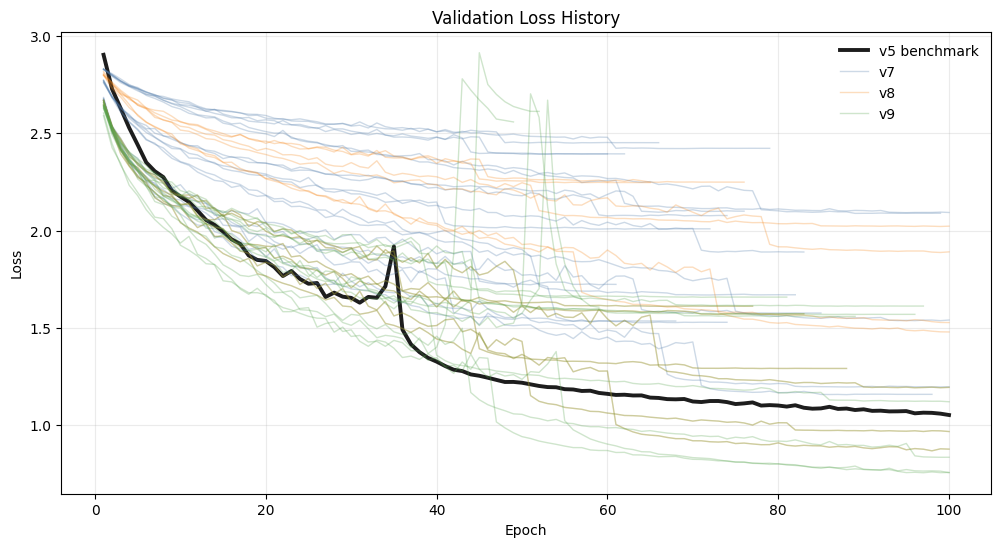

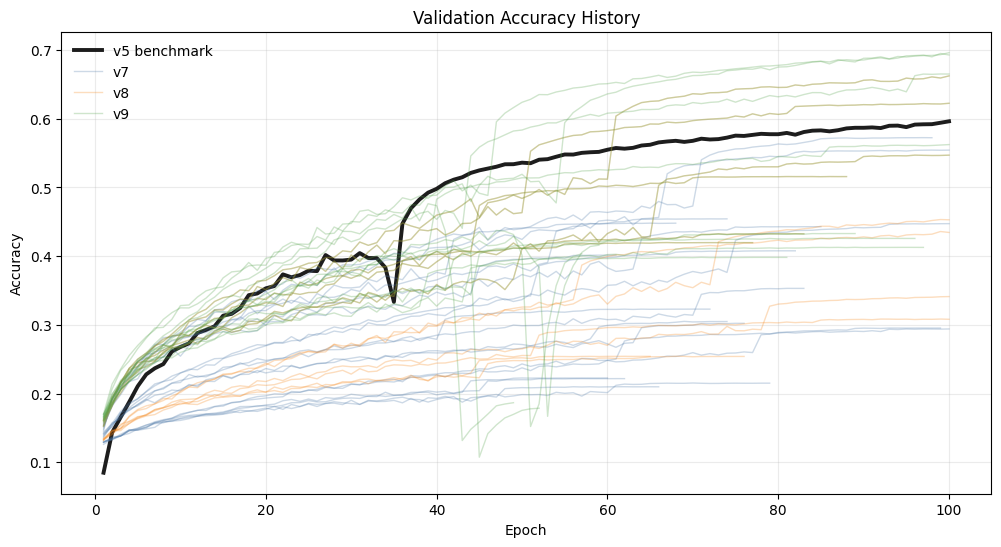

In [88]:
def plot_history_metric(metric, ylabel, better="lower"):
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = {"v7": "#4c78a8", "v8": "#f58518", "v9": "#54a24b", "v5": "#111111"}
    for _, run in summary_df.sort_values(["version", "model_name"]).iterrows():
        data = epoch_df.loc[epoch_df["run_id"].eq(run["run_id"])]
        if data.empty or metric not in data:
            continue
        is_benchmark = run["version"] == BENCHMARK_VERSION
        ax.plot(
            data["epoch"],
            data[metric],
            color=colors.get(run["version"], "#999999"),
            alpha=0.95 if is_benchmark else 0.28,
            linewidth=2.8 if is_benchmark else 1.0,
            label="v5 benchmark" if is_benchmark else run["version"],
        )
    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), frameon=False)
    ax.set_title(f"Validation {ylabel} History")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    return fig, ax

plot_history_metric("val_loss", "Loss")
plot_history_metric("val_accuracy", "Accuracy", better="higher")
plt.show()


## Test Metrics by Configuration

The vertical dashed lines are v5 benchmark values. Points left of the loss line or above the accuracy line improve on v5 for that metric.


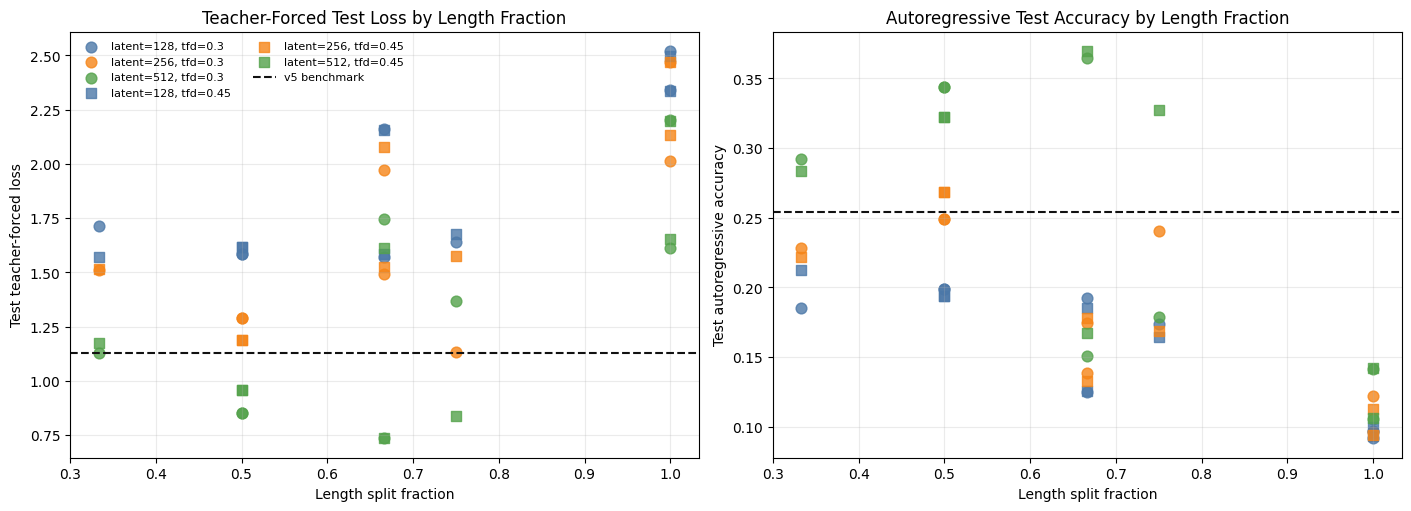

In [89]:
plot_df = summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])].copy()
plot_df["length_label"] = plot_df["length_group"].astype(str)
plot_df["tfd_label"] = plot_df["teacher_forcing_dropout"].map(lambda x: f"tfd={x:g}" if pd.notna(x) else "tfd=?")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
markers = {0.3: "o", 0.45: "s"}
colors = {128: "#4c78a8", 256: "#f58518", 512: "#54a24b"}

for tfd, tfd_df in plot_df.groupby("teacher_forcing_dropout", dropna=False):
    for latent, latent_df in tfd_df.groupby("latent_dim", dropna=False):
        axes[0].scatter(
            latent_df["length_fraction"],
            latent_df["test_tf_loss"],
            label=f"latent={latent}, tfd={tfd:g}",
            marker=markers.get(tfd, "x"),
            color=colors.get(latent, "#999999"),
            alpha=0.8,
            s=60,
        )
        axes[1].scatter(
            latent_df["length_fraction"],
            latent_df["test_ar_accuracy"],
            marker=markers.get(tfd, "x"),
            color=colors.get(latent, "#999999"),
            alpha=0.8,
            s=60,
        )

axes[0].axhline(benchmark["test_tf_loss"], color="#111111", linestyle="--", linewidth=1.5, label="v5 benchmark")
axes[1].axhline(benchmark["test_ar_accuracy"], color="#111111", linestyle="--", linewidth=1.5, label="v5 benchmark")
axes[0].set_title("Teacher-Forced Test Loss by Length Fraction")
axes[1].set_title("Autoregressive Test Accuracy by Length Fraction")
for ax in axes:
    ax.set_xlabel("Length split fraction")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Test teacher-forced loss")
axes[1].set_ylabel("Test autoregressive accuracy")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, frameon=False, fontsize=8, ncols=2)
plt.show()


## Error Pattern 1: Length Split

This aggregates deltas by version and length split. It is useful for spotting whether errors concentrate on longer sequence buckets.


In [90]:
length_summary = (
    summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])]
    .groupby(["version", "length_group", "length_fraction"], dropna=False)
    .agg(
        runs=("run_id", "count"),
        mean_tf_loss_delta=("delta_vs_v5_test_tf_loss", "mean"),
        best_tf_loss_delta=("delta_vs_v5_test_tf_loss", "min"),
        mean_tf_accuracy_delta=("delta_vs_v5_test_tf_accuracy", "mean"),
        best_tf_accuracy_delta=("delta_vs_v5_test_tf_accuracy", "max"),
        mean_ar_loss_delta=("delta_vs_v5_test_ar_loss", "mean"),
        best_ar_accuracy_delta=("delta_vs_v5_test_ar_accuracy", "max"),
        mean_generalization_gap=("loss_generalization_gap_final", "mean"),
    )
    .reset_index()
    .sort_values(["version", "length_fraction"])
)
length_summary


,version,length_group,length_fraction,runs,mean_tf_loss_delta,best_tf_loss_delta,mean_tf_accuracy_delta,best_tf_accuracy_delta,mean_ar_loss_delta,best_ar_accuracy_delta,mean_generalization_gap
0,v7,1/3,0.333333,6,0.305310,-0.000242,-0.090176,0.007446,-0.250534,0.038601,0.339218
1,v7,2/3,0.666667,6,0.823070,0.482242,-0.241498,-0.149007,-0.200722,-0.086653,0.276791
2,v7,3/3,1.000000,6,1.261799,1.065433,-0.360170,-0.311413,-0.232676,-0.147746,0.190277
3,v8,1/2,0.500000,6,0.118460,-0.276622,-0.035322,0.092137,-0.162786,0.090316,0.197905
4,v8,2/2,1.000000,6,0.884257,0.479943,-0.265936,-0.159270,-0.100452,-0.111392,0.119943
5,v9,1/2,0.500000,6,0.118460,-0.276622,-0.035322,0.092137,-0.162786,0.090316,0.197905
6,v9,2/3,0.666667,6,0.143072,-0.395645,-0.049201,0.128179,-0.082378,0.115866,0.057508
7,v9,3/4,0.750000,6,0.240588,-0.292755,-0.083677,0.094428,-0.011522,0.073245,0.055723


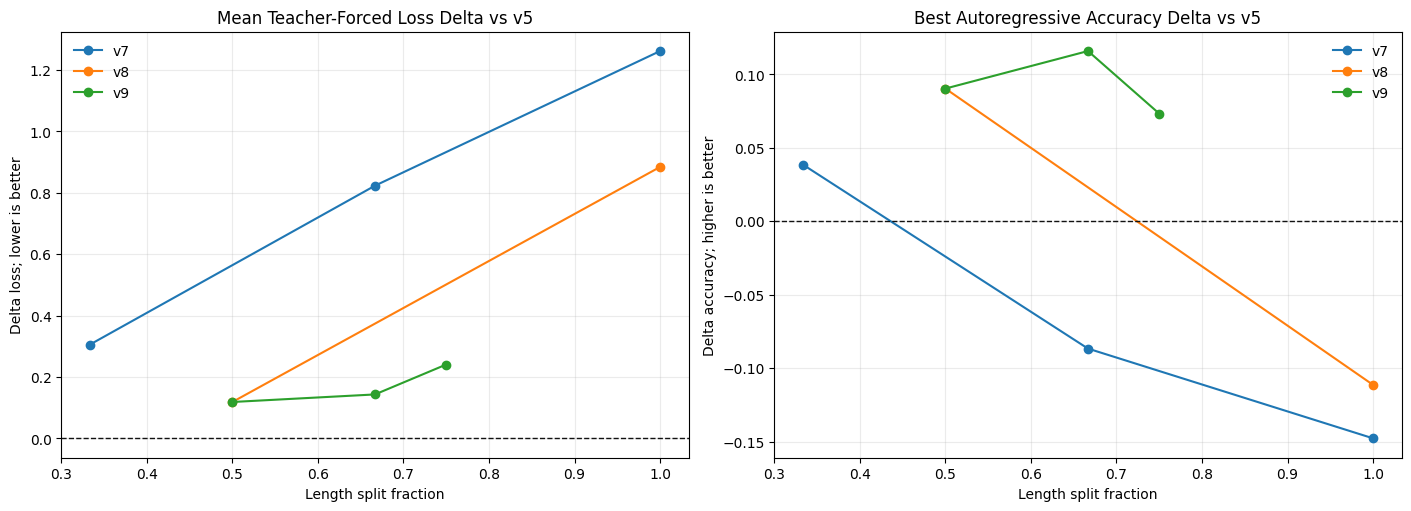

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for version, group in length_summary.groupby("version"):
    axes[0].plot(group["length_fraction"], group["mean_tf_loss_delta"], marker="o", label=version)
    axes[1].plot(group["length_fraction"], group["best_ar_accuracy_delta"], marker="o", label=version)
for ax in axes:
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_xlabel("Length split fraction")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
axes[0].set_title("Mean Teacher-Forced Loss Delta vs v5")
axes[0].set_ylabel("Delta loss; lower is better")
axes[1].set_title("Best Autoregressive Accuracy Delta vs v5")
axes[1].set_ylabel("Delta accuracy; higher is better")
plt.show()


## Error Pattern 2: Latent Dimension and Teacher-Forcing Dropout

This checks whether model capacity or teacher-forcing dropout explains the strongest failures and wins.


In [92]:
config_summary = (
    summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])]
    .groupby(["latent_dim", "teacher_forcing_dropout"], dropna=False)
    .agg(
        runs=("run_id", "count"),
        mean_tf_loss=("test_tf_loss", "mean"),
        mean_tf_loss_delta=("delta_vs_v5_test_tf_loss", "mean"),
        best_tf_loss_delta=("delta_vs_v5_test_tf_loss", "min"),
        mean_tf_accuracy_delta=("delta_vs_v5_test_tf_accuracy", "mean"),
        mean_ar_accuracy_delta=("delta_vs_v5_test_ar_accuracy", "mean"),
        best_ar_accuracy_delta=("delta_vs_v5_test_ar_accuracy", "max"),
        mean_val_loss_drift=("val_loss_drift_after_best", "mean"),
        mean_loss_gap=("loss_generalization_gap_final", "mean"),
    )
    .reset_index()
    .sort_values(["latent_dim", "teacher_forcing_dropout"])
)
config_summary


,latent_dim,teacher_forcing_dropout,runs,mean_tf_loss,mean_tf_loss_delta,best_tf_loss_delta,mean_tf_accuracy_delta,mean_ar_accuracy_delta,best_ar_accuracy_delta,mean_val_loss_drift,mean_loss_gap
0,128,0.30,8,1.889651,0.758588,0.440048,-0.223664,-0.095925,-0.054745,0.002248,0.226575
1,128,0.45,8,1.881884,0.750821,0.438933,-0.222603,-0.095307,-0.041564,0.000868,0.198995
2,256,0.30,8,1.646709,0.515646,0.001102,-0.156355,-0.066502,-0.004495,0.019148,0.189512
3,256,0.45,8,1.710999,0.579936,0.059589,-0.175017,-0.073174,0.014830,0.138688,0.154128
4,512,0.30,8,1.312263,0.181200,-0.395645,-0.054394,-0.013601,0.110599,0.151829,0.162139
5,512,0.45,8,1.266134,0.135071,-0.394814,-0.038945,0.001170,0.115866,0.000699,0.145104


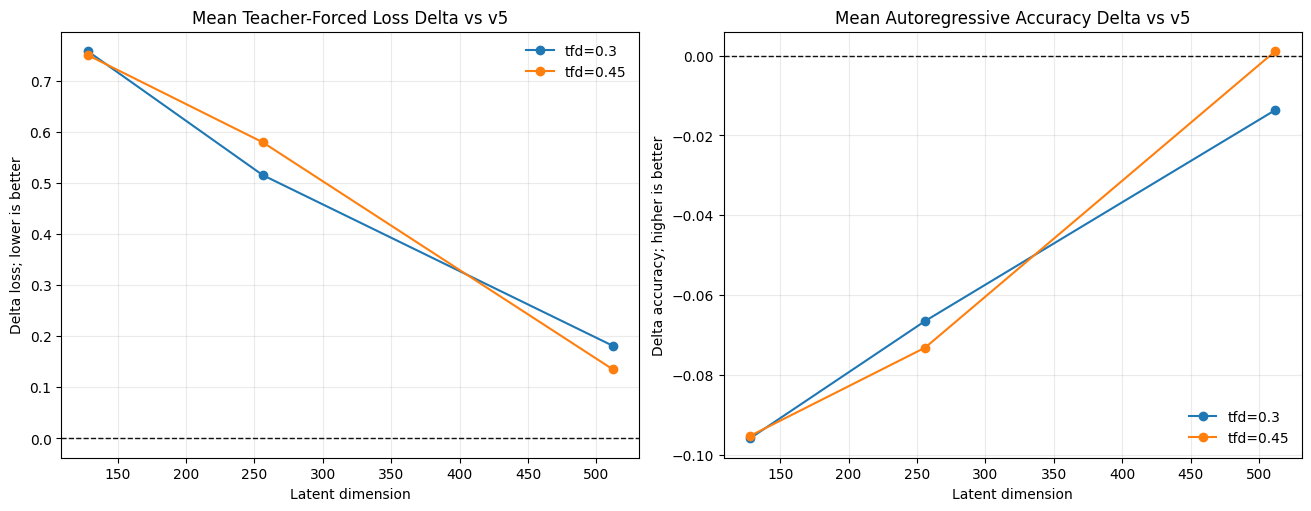

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for tfd, group in config_summary.groupby("teacher_forcing_dropout"):
    axes[0].plot(group["latent_dim"], group["mean_tf_loss_delta"], marker="o", label=f"tfd={tfd:g}")
    axes[1].plot(group["latent_dim"], group["mean_ar_accuracy_delta"], marker="o", label=f"tfd={tfd:g}")
for ax in axes:
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_xlabel("Latent dimension")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
axes[0].set_title("Mean Teacher-Forced Loss Delta vs v5")
axes[0].set_ylabel("Delta loss; lower is better")
axes[1].set_title("Mean Autoregressive Accuracy Delta vs v5")
axes[1].set_ylabel("Delta accuracy; higher is better")
plt.show()


## Error Pattern 3: Validation Drift and Generalization Gap

Large positive validation drift means the final checkpoint is worse than the best validation epoch. Large final loss gap means validation loss remains much higher than training loss.


In [94]:
drift_cols = [
    "version",
    "model_name",
    "length_group",
    "latent_dim",
    "teacher_forcing_dropout",
    "epochs_completed",
    "best_val_loss_epoch",
    "val_loss_drift_after_best",
    "loss_generalization_gap_final",
    "tail_val_loss_std",
    "test_tf_loss",
    "delta_vs_v5_test_tf_loss",
]
summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"]), drift_cols].sort_values(
    ["val_loss_drift_after_best", "loss_generalization_gap_final"], ascending=False
).head(15)


,version,model_name,length_group,latent_dim,teacher_forcing_dropout,epochs_completed,best_val_loss_epoch,val_loss_drift_after_best,loss_generalization_gap_final,tail_val_loss_std,test_tf_loss,delta_vs_v5_test_tf_loss
47,v9,model_ae_length_3_of_4_solubility_latent512_tf...,3/4,512,0.30,49,39,1.192077,-0.008810,0.523569,1.366633,0.235570
46,v9,model_ae_length_3_of_4_solubility_latent256_tf...,3/4,256,0.45,52,42,1.041787,0.005449,0.458394,1.575520,0.444457
39,v9,model_ae_length_2_of_3_solubility_latent256_tf...,2/3,256,0.30,57,47,0.145895,-0.017540,0.433086,1.492183,0.361120
40,v9,model_ae_length_2_of_3_solubility_latent256_tf...,2/3,256,0.45,59,49,0.057656,-0.010378,0.335223,1.526470,0.395407
23,v8,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.30,100,98,0.008785,0.178178,0.006486,0.854441,-0.276622
35,v9,model_ae_length_1_of_2_solubility_latent512_tf...,1/2,512,0.30,100,98,0.008785,0.178178,0.006486,0.854441,-0.276622
7,v7,model_ae_length_2_of_3_solubility_latent128_tf...,2/3,128,0.30,76,66,0.005311,0.303035,0.002804,2.161547,1.030484
19,v8,model_ae_length_1_of_2_solubility_latent128_tf...,1/2,128,0.30,83,73,0.003314,0.263916,0.000524,1.584495,0.453432
31,v9,model_ae_length_1_of_2_solubility_latent128_tf...,1/2,128,0.30,83,73,0.003314,0.263916,0.000524,1.584495,0.453432
12,v7,model_ae_length_2_of_3_solubility_latent512_tf...,2/3,512,0.45,100,99,0.003244,0.267555,0.006012,1.613305,0.482242


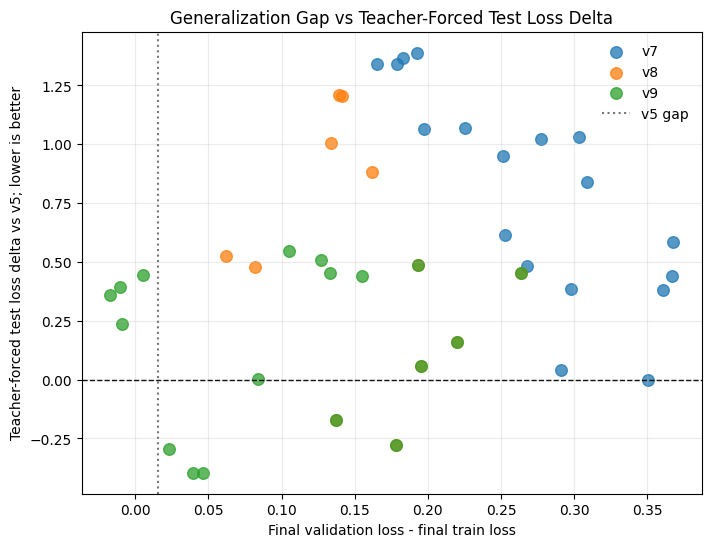

In [95]:
fig, ax = plt.subplots(figsize=(8, 6))
for version, group in summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])].groupby("version"):
    ax.scatter(
        group["loss_generalization_gap_final"],
        group["delta_vs_v5_test_tf_loss"],
        s=70,
        alpha=0.75,
        label=version,
    )
ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
ax.axvline(benchmark["loss_generalization_gap_final"], color="#777777", linestyle=":", linewidth=1.5, label="v5 gap")
ax.set_title("Generalization Gap vs Teacher-Forced Test Loss Delta")
ax.set_xlabel("Final validation loss - final train loss")
ax.set_ylabel("Teacher-forced test loss delta vs v5; lower is better")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.show()


## Potential Duplicate or Repeated Results

This flags checkpoints with identical test metrics. These may be intentional reruns, copied evaluations, or evidence that two versions point to the same checkpoint family.


In [96]:
duplicate_metric_cols = ["test_tf_loss", "test_ar_loss", "test_tf_accuracy", "test_ar_accuracy"]
duplicates = (
    summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])]
    .assign(metric_signature=lambda df: df[duplicate_metric_cols].round(6).astype(str).agg("|".join, axis=1))
)
duplicate_groups = duplicates.groupby("metric_signature").filter(lambda g: len(g) > 1)
duplicate_groups[["version", "model_name", *duplicate_metric_cols]].sort_values(duplicate_metric_cols)


,version,model_name,test_tf_loss,test_ar_loss,test_tf_accuracy,test_ar_accuracy
23,v8,model_ae_length_1_of_2_solubility_latent512_tf...,0.854441,3.314992,0.673997,0.344088
35,v9,model_ae_length_1_of_2_solubility_latent512_tf...,0.854441,3.314992,0.673997,0.344088
24,v8,model_ae_length_1_of_2_solubility_latent512_tf...,0.958431,3.045857,0.638494,0.321934
36,v9,model_ae_length_1_of_2_solubility_latent512_tf...,0.958431,3.045857,0.638494,0.321934
22,v8,model_ae_length_1_of_2_solubility_latent256_tf...,1.190652,3.179304,0.562369,0.268602
34,v9,model_ae_length_1_of_2_solubility_latent256_tf...,1.190652,3.179304,0.562369,0.268602
21,v8,model_ae_length_1_of_2_solubility_latent256_tf...,1.291442,3.178959,0.528888,0.249277
33,v9,model_ae_length_1_of_2_solubility_latent256_tf...,1.291442,3.178959,0.528888,0.249277
19,v8,model_ae_length_1_of_2_solubility_latent128_tf...,1.584495,3.263140,0.444430,0.199027
31,v9,model_ae_length_1_of_2_solubility_latent128_tf...,1.584495,3.263140,0.444430,0.199027


## Generated Takeaways

This cell prints a compact interpretation from the loaded metrics. Re-run it after adding histories or refreshing the results CSV.


In [97]:
def fmt_delta(value, metric_type):
    if pd.isna(value):
        return "NA"
    sign = "+" if value >= 0 else ""
    if metric_type == "accuracy":
        return f"{sign}{value:.4f}"
    return f"{sign}{value:.4f}"

candidate_df = summary_df.loc[summary_df["version"].isin(["v7", "v8", "v9"])].copy()
best_tf = candidate_df.sort_values("test_tf_loss").iloc[0]
best_ar = candidate_df.sort_values("test_ar_accuracy", ascending=False).iloc[0]
worst_tf = candidate_df.sort_values("test_tf_loss", ascending=False).iloc[0]
by_version = candidate_df.groupby("version").agg(
    runs=("run_id", "count"),
    best_tf_loss_delta=("delta_vs_v5_test_tf_loss", "min"),
    best_ar_accuracy_delta=("delta_vs_v5_test_ar_accuracy", "max"),
    median_tf_loss_delta=("delta_vs_v5_test_tf_loss", "median"),
    median_ar_accuracy_delta=("delta_vs_v5_test_ar_accuracy", "median"),
)

print("Benchmark v5:")
print(f"  TF loss={benchmark['test_tf_loss']:.4f}, TF accuracy={benchmark['test_tf_accuracy']:.4f}")
print(f"  AR loss={benchmark['test_ar_loss']:.4f}, AR accuracy={benchmark['test_ar_accuracy']:.4f}")
print()
print("Best teacher-forced loss among v7-v9:")
print(f"  {best_tf['version']} {best_tf['model_name']}")
print(f"  TF loss={best_tf['test_tf_loss']:.4f} ({fmt_delta(best_tf['delta_vs_v5_test_tf_loss'], 'loss')} vs v5)")
print(f"  AR accuracy={best_tf['test_ar_accuracy']:.4f} ({fmt_delta(best_tf['delta_vs_v5_test_ar_accuracy'], 'accuracy')} vs v5)")
print()
print("Best autoregressive accuracy among v7-v9:")
print(f"  {best_ar['version']} {best_ar['model_name']}")
print(f"  AR accuracy={best_ar['test_ar_accuracy']:.4f} ({fmt_delta(best_ar['delta_vs_v5_test_ar_accuracy'], 'accuracy')} vs v5)")
print(f"  TF loss={best_ar['test_tf_loss']:.4f} ({fmt_delta(best_ar['delta_vs_v5_test_tf_loss'], 'loss')} vs v5)")
print()
print("Worst teacher-forced loss among v7-v9:")
print(f"  {worst_tf['version']} {worst_tf['model_name']}")
print(f"  TF loss={worst_tf['test_tf_loss']:.4f} ({fmt_delta(worst_tf['delta_vs_v5_test_tf_loss'], 'loss')} vs v5)")
print()
print("By-version summary:")
display(by_version)


Benchmark v5:
  TF loss=1.1311, TF accuracy=0.5819
  AR loss=3.3443, AR accuracy=0.2538

Best teacher-forced loss among v7-v9:
  v9 model_ae_length_2_of_3_solubility_latent512_tfd0p3
  TF loss=0.7354 (-0.3956 vs v5)
  AR accuracy=0.3644 (+0.1106 vs v5)

Best autoregressive accuracy among v7-v9:
  v9 model_ae_length_2_of_3_solubility_latent512_tfd0p45
  AR accuracy=0.3696 (+0.1159 vs v5)
  TF loss=0.7362 (-0.3948 vs v5)

Worst teacher-forced loss among v7-v9:
  v7 model_ae_length_3_of_3_solubility_latent128_tfd0p3
  TF loss=2.5204 (+1.3893 vs v5)

By-version summary:


,runs,best_tf_loss_delta,best_ar_accuracy_delta,median_tf_loss_delta,median_ar_accuracy_delta
version,,,,,
v7,18,-0.000242,0.038601,0.894374,-0.118235
v8,12,-0.276622,0.090316,0.483279,-0.085731
v9,18,-0.395645,0.115866,0.298345,-0.057408


## Suggested Follow-Up Checks

- If a checkpoint beats v5 on teacher-forced loss but not autoregressive accuracy, inspect free-running decoded sequences for compounding decoder errors.
- If longer length splits have worse deltas, run per-sequence reconstruction analysis stratified by target length once prediction CSVs are available.
- If final validation drift is large, compare the saved checkpoint policy to the best-validation epoch; the test metric may reflect the final epoch rather than the best epoch.
- If duplicate metric signatures are unexpected, verify the checkpoint paths used by the evaluation script before treating those runs as independent evidence.


## Analysis Takeaways

The v5 benchmark has teacher-forced loss `1.1311`, teacher-forced accuracy `0.5819`, autoregressive loss `3.3443`, and autoregressive accuracy `0.2538`.

The strongest overall results are from v9 with latent dimension `512`. The best teacher-forced loss is `v9/model_ae_length_2_of_3_solubility_latent512_tfd0p3`, with teacher-forced loss `0.7354` (`-0.3956` vs v5), teacher-forced accuracy `0.7090` (`+0.1271`), and autoregressive accuracy `0.3644` (`+0.1106`). The best autoregressive accuracy is `v9/model_ae_length_2_of_3_solubility_latent512_tfd0p45`, with autoregressive accuracy `0.3696` (`+0.1159`) and nearly identical teacher-forced loss `0.7362` (`-0.3948`).

Version-level performance improves from v7 to v8 to v9. v7 has only one checkpoint that beats v5 on teacher-forced loss and two that beat v5 on autoregressive accuracy. v8 improves but is still mixed. v9 has five checkpoints that beat v5 on teacher-forced loss and six that beat v5 on autoregressive accuracy, making it the strongest checkpoint family.

Most of the useful improvement comes from latent dimension `512`. Latent `128` and `256` generally remain worse than v5 on accuracy, especially on longer length splits. Length remains a major error factor: v7 degrades strongly from `1/3` to `3/3`, v8 degrades at `2/2`, and v9 handles longer splits better, especially `2/3` and `3/4` with latent `512`.

The `length_1_of_2` checkpoints in v8 and v9 have identical test metrics, so those should not be interpreted as independent results unless that reuse was intentional. The next useful analysis is per-sequence reconstruction error for the two v9 latent512 candidates, stratified by sequence length, amino acid class, and length mismatch or early-stop behavior.


## V9 Dataset Size Split Performance

From this point on, the analysis focuses only on v9. The v9 checkpoint names encode three dataset/length split groups: `1/2`, `2/3`, and `3/4`. The summary below compares each split using both average performance across all latent/dropout settings and the best checkpoint within that split.

Interpretation: lower teacher-forced loss is better; higher autoregressive accuracy is better. Bars show the split average, and points show the best checkpoint in that split.


In [98]:
v9_df = summary_df.loc[summary_df["version"].eq("v9")].copy()
v9_df["split_label"] = v9_df["length_group"]

v9_split_summary = (
    v9_df.groupby(["split_label", "length_fraction"], dropna=False)
    .agg(
        runs=("run_id", "count"),
        mean_tf_loss=("test_tf_loss", "mean"),
        best_tf_loss=("test_tf_loss", "min"),
        mean_tf_accuracy=("test_tf_accuracy", "mean"),
        best_tf_accuracy=("test_tf_accuracy", "max"),
        mean_ar_loss=("test_ar_loss", "mean"),
        best_ar_loss=("test_ar_loss", "min"),
        mean_ar_accuracy=("test_ar_accuracy", "mean"),
        best_ar_accuracy=("test_ar_accuracy", "max"),
    )
    .reset_index()
    .sort_values("length_fraction")
)

v9_split_summary


,split_label,length_fraction,runs,mean_tf_loss,best_tf_loss,mean_tf_accuracy,best_tf_accuracy,mean_ar_loss,best_ar_loss,mean_ar_accuracy,best_ar_accuracy
0,1/2,0.500000,6,1.249523,0.854441,0.546538,0.673997,3.181555,3.045857,0.262771,0.344088
1,2/3,0.666667,6,1.274135,0.735418,0.532659,0.710039,3.261963,3.184764,0.243991,0.369638
2,3/4,0.750000,6,1.371651,0.838308,0.498183,0.676288,3.332819,3.197613,0.209016,0.327017


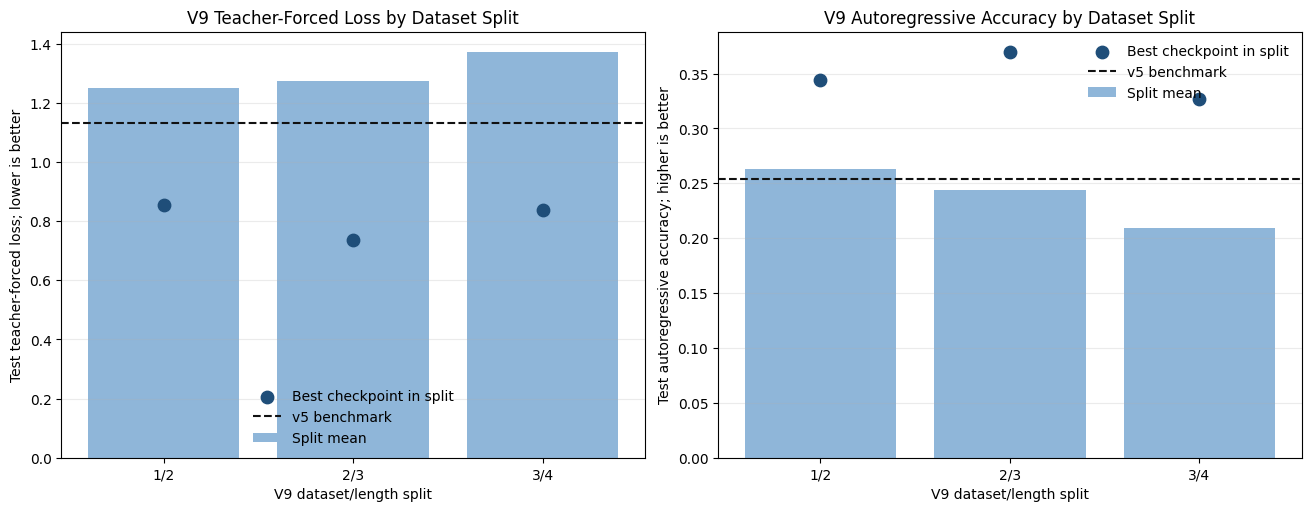

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

x = range(len(v9_split_summary))
labels = v9_split_summary["split_label"].tolist()
bar_color = "#8fb6d9"
best_color = "#1f4e79"
benchmark_color = "#111111"

axes[0].bar(x, v9_split_summary["mean_tf_loss"], color=bar_color, label="Split mean")
axes[0].scatter(x, v9_split_summary["best_tf_loss"], color=best_color, s=80, zorder=3, label="Best checkpoint in split")
axes[0].axhline(benchmark["test_tf_loss"], color=benchmark_color, linestyle="--", linewidth=1.5, label="v5 benchmark")
axes[0].set_title("V9 Teacher-Forced Loss by Dataset Split")
axes[0].set_ylabel("Test teacher-forced loss; lower is better")

axes[1].bar(x, v9_split_summary["mean_ar_accuracy"], color=bar_color, label="Split mean")
axes[1].scatter(x, v9_split_summary["best_ar_accuracy"], color=best_color, s=80, zorder=3, label="Best checkpoint in split")
axes[1].axhline(benchmark["test_ar_accuracy"], color=benchmark_color, linestyle="--", linewidth=1.5, label="v5 benchmark")
axes[1].set_title("V9 Autoregressive Accuracy by Dataset Split")
axes[1].set_ylabel("Test autoregressive accuracy; higher is better")

for ax in axes:
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_xlabel("V9 dataset/length split")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)

plt.show()


In [100]:
best_v9_tf_split = v9_split_summary.loc[v9_split_summary["best_tf_loss"].idxmin()]
best_v9_ar_split = v9_split_summary.loc[v9_split_summary["best_ar_accuracy"].idxmax()]
mean_v9_tf_split = v9_split_summary.loc[v9_split_summary["mean_tf_loss"].idxmin()]
mean_v9_ar_split = v9_split_summary.loc[v9_split_summary["mean_ar_accuracy"].idxmax()]

print("Best individual checkpoint by teacher-forced loss is in split:", best_v9_tf_split["split_label"])
print(f"  best TF loss={best_v9_tf_split['best_tf_loss']:.4f}")
print("Best individual checkpoint by autoregressive accuracy is in split:", best_v9_ar_split["split_label"])
print(f"  best AR accuracy={best_v9_ar_split['best_ar_accuracy']:.4f}")
print()
print("Best split average by teacher-forced loss is:", mean_v9_tf_split["split_label"])
print(f"  mean TF loss={mean_v9_tf_split['mean_tf_loss']:.4f}")
print("Best split average by autoregressive accuracy is:", mean_v9_ar_split["split_label"])
print(f"  mean AR accuracy={mean_v9_ar_split['mean_ar_accuracy']:.4f}")


Best individual checkpoint by teacher-forced loss is in split: 2/3
  best TF loss=0.7354
Best individual checkpoint by autoregressive accuracy is in split: 2/3
  best AR accuracy=0.3696

Best split average by teacher-forced loss is: 1/2
  mean TF loss=1.2495
Best split average by autoregressive accuracy is: 1/2
  mean AR accuracy=0.2628


### V9 Dataset Split Takeaway

The best individual v9 checkpoints are in the `2/3` split. That split contains both the lowest teacher-forced loss checkpoint and the highest autoregressive accuracy checkpoint, driven by latent dimension `512`.

By split average, `1/2` is slightly better than `2/3`, because the weaker latent `128` and `256` checkpoints pull down the `2/3` average. For model selection, the `2/3` split is the stronger choice because its best latent512 checkpoints clearly outperform the best checkpoints from the other v9 splits.


## V9 2/3 Split Loss Curves

This section isolates the v9 checkpoints trained/evaluated on the `2/3` split and plots loss over epochs for each checkpoint. Solid lines are validation loss and lighter dashed lines are training loss for the same checkpoint.


In [101]:
v9_2of3_runs = (
    summary_df.loc[
        summary_df["version"].eq("v9")
        & summary_df["length_group"].eq("2/3")
    ]
    .sort_values(["latent_dim", "teacher_forcing_dropout"])
    .copy()
)

v9_2of3_epoch_df = epoch_df.loc[epoch_df["run_id"].isin(v9_2of3_runs["run_id"])].copy()
v9_2of3_epoch_df = v9_2of3_epoch_df.merge(
    v9_2of3_runs[["run_id", "latent_dim", "teacher_forcing_dropout", "model_name"]],
    on="run_id",
    how="left",
    suffixes=("", "_run"),
)
v9_2of3_epoch_df["curve_label"] = v9_2of3_epoch_df.apply(
    lambda row: f"latent {int(row['latent_dim'])}, tfd {row['teacher_forcing_dropout']:g}",
    axis=1,
)

v9_2of3_runs[[
    "model_name",
    "latent_dim",
    "teacher_forcing_dropout",
    "epochs_completed",
    "best_val_loss",
    "best_val_loss_epoch",
    "test_tf_loss",
    "test_ar_accuracy",
]]


,model_name,latent_dim,teacher_forcing_dropout,epochs_completed,best_val_loss,best_val_loss_epoch,test_tf_loss,test_ar_accuracy
37,model_ae_length_2_of_3_solubility_latent128_tf...,128,0.30,89,1.556953,79,1.571111,0.192042
38,model_ae_length_2_of_3_solubility_latent128_tf...,128,0.45,96,1.568180,86,1.583381,0.185337
39,model_ae_length_2_of_3_solubility_latent256_tf...,256,0.30,57,1.500889,47,1.492183,0.174671
40,model_ae_length_2_of_3_solubility_latent256_tf...,256,0.45,59,1.548221,49,1.526470,0.177889
41,model_ae_length_2_of_3_solubility_latent512_tf...,512,0.30,100,0.753443,97,0.735418,0.364371
42,model_ae_length_2_of_3_solubility_latent512_tf...,512,0.45,100,0.753699,100,0.736249,0.369638


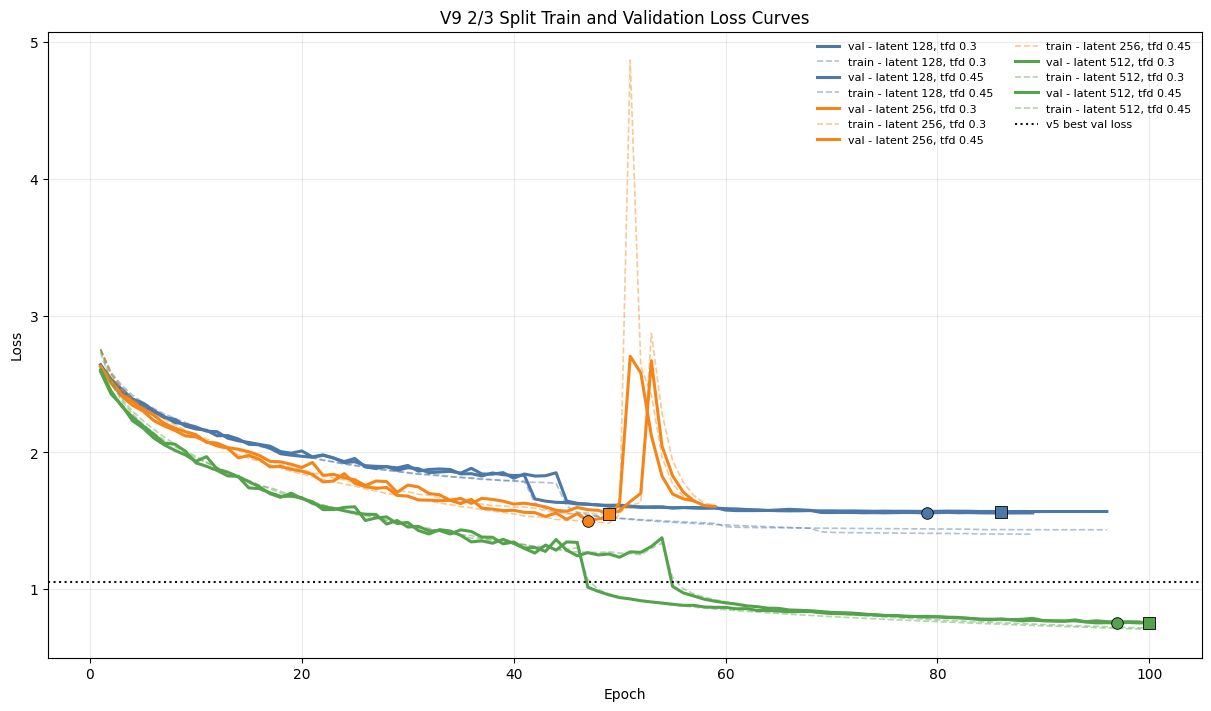

In [102]:
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

colors = {
    128: "#4c78a8",
    256: "#f58518",
    512: "#54a24b",
}
linestyles = {
    0.3: "-",
    0.45: "-",
}
markers = {
    0.3: "o",
    0.45: "s",
}

for _, run in v9_2of3_runs.iterrows():
    data = v9_2of3_epoch_df.loc[v9_2of3_epoch_df["run_id"].eq(run["run_id"])].sort_values("epoch")
    color = colors.get(run["latent_dim"], "#999999")
    label = f"latent {int(run['latent_dim'])}, tfd {run['teacher_forcing_dropout']:g}"

    ax.plot(
        data["epoch"],
        data["val_loss"],
        color=color,
        linestyle=linestyles.get(run["teacher_forcing_dropout"], "-"),
        linewidth=2.2,
        label=f"val - {label}",
    )
    ax.plot(
        data["epoch"],
        data["train_loss"],
        color=color,
        linestyle="--",
        linewidth=1.2,
        alpha=0.45,
        label=f"train - {label}",
    )
    best_epoch = run["best_val_loss_epoch"]
    best_loss = run["best_val_loss"]
    ax.scatter(
        [best_epoch],
        [best_loss],
        color=color,
        marker=markers.get(run["teacher_forcing_dropout"], "o"),
        edgecolor="black",
        linewidth=0.6,
        s=70,
        zorder=4,
    )

ax.axhline(benchmark["best_val_loss"], color="#111111", linestyle=":", linewidth=1.5, label="v5 best val loss")
ax.set_title("V9 2/3 Split Train and Validation Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8, ncols=2)
plt.show()


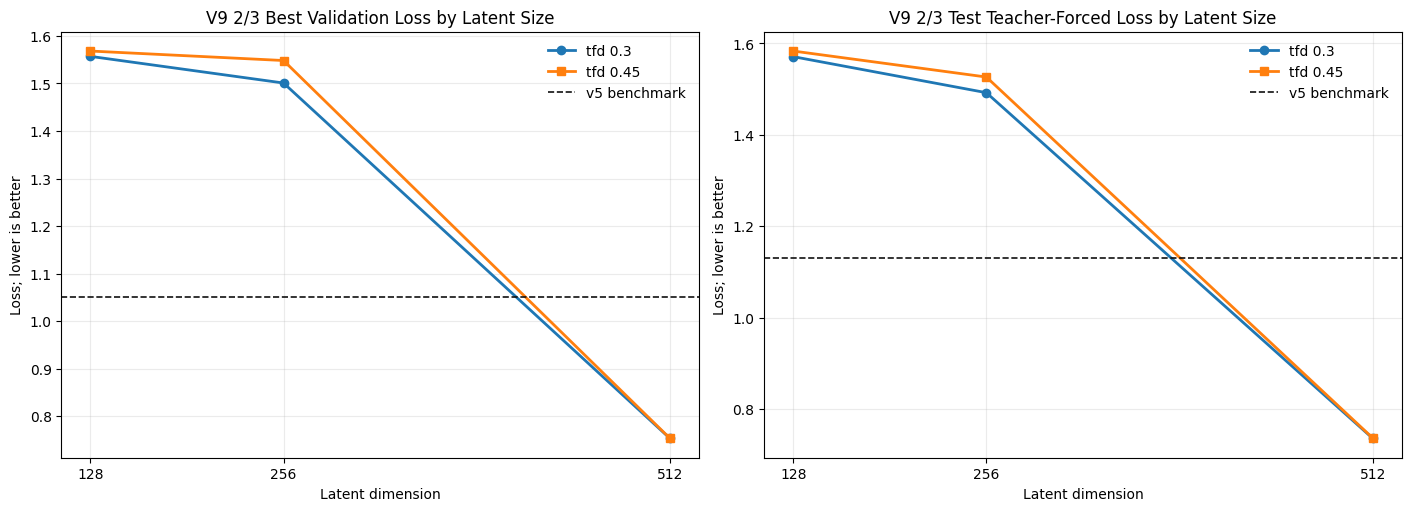

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for tfd, marker in [(0.3, "o"), (0.45, "s")]:
    subset = v9_2of3_runs.loc[v9_2of3_runs["teacher_forcing_dropout"].eq(tfd)].sort_values("latent_dim")
    axes[0].plot(
        subset["latent_dim"],
        subset["best_val_loss"],
        marker=marker,
        linewidth=2,
        label=f"tfd {tfd:g}",
    )
    axes[1].plot(
        subset["latent_dim"],
        subset["test_tf_loss"],
        marker=marker,
        linewidth=2,
        label=f"tfd {tfd:g}",
    )

axes[0].axhline(benchmark["best_val_loss"], color="#111111", linestyle="--", linewidth=1.2, label="v5 benchmark")
axes[1].axhline(benchmark["test_tf_loss"], color="#111111", linestyle="--", linewidth=1.2, label="v5 benchmark")
axes[0].set_title("V9 2/3 Best Validation Loss by Latent Size")
axes[1].set_title("V9 2/3 Test Teacher-Forced Loss by Latent Size")
for ax in axes:
    ax.set_xlabel("Latent dimension")
    ax.set_ylabel("Loss; lower is better")
    ax.set_xticks(sorted(v9_2of3_runs["latent_dim"].unique()))
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.show()


## V9 2/3 Split Accuracy Curves

This uses the same v9 `2/3` checkpoint subset as the loss curves. Solid lines are validation accuracy and lighter dashed lines are training accuracy for the same checkpoint.


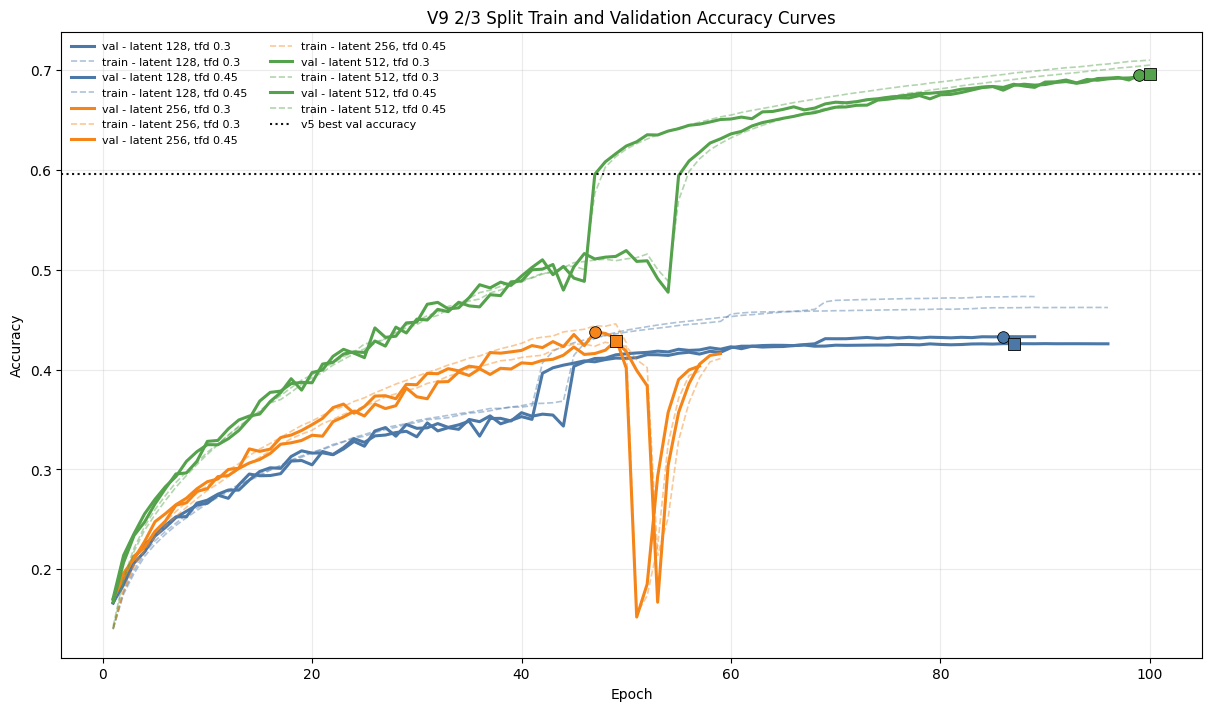

In [104]:
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for _, run in v9_2of3_runs.iterrows():
    data = v9_2of3_epoch_df.loc[v9_2of3_epoch_df["run_id"].eq(run["run_id"])].sort_values("epoch")
    color = colors.get(run["latent_dim"], "#999999")
    label = f"latent {int(run['latent_dim'])}, tfd {run['teacher_forcing_dropout']:g}"

    ax.plot(
        data["epoch"],
        data["val_accuracy"],
        color=color,
        linestyle=linestyles.get(run["teacher_forcing_dropout"], "-"),
        linewidth=2.2,
        label=f"val - {label}",
    )
    ax.plot(
        data["epoch"],
        data["train_accuracy"],
        color=color,
        linestyle="--",
        linewidth=1.2,
        alpha=0.45,
        label=f"train - {label}",
    )
    best_epoch = run["best_val_accuracy_epoch"]
    best_accuracy = run["best_val_accuracy"]
    ax.scatter(
        [best_epoch],
        [best_accuracy],
        color=color,
        marker=markers.get(run["teacher_forcing_dropout"], "o"),
        edgecolor="black",
        linewidth=0.6,
        s=70,
        zorder=4,
    )

ax.axhline(benchmark["best_val_accuracy"], color="#111111", linestyle=":", linewidth=1.5, label="v5 best val accuracy")
ax.set_title("V9 2/3 Split Train and Validation Accuracy Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8, ncols=2)
plt.show()


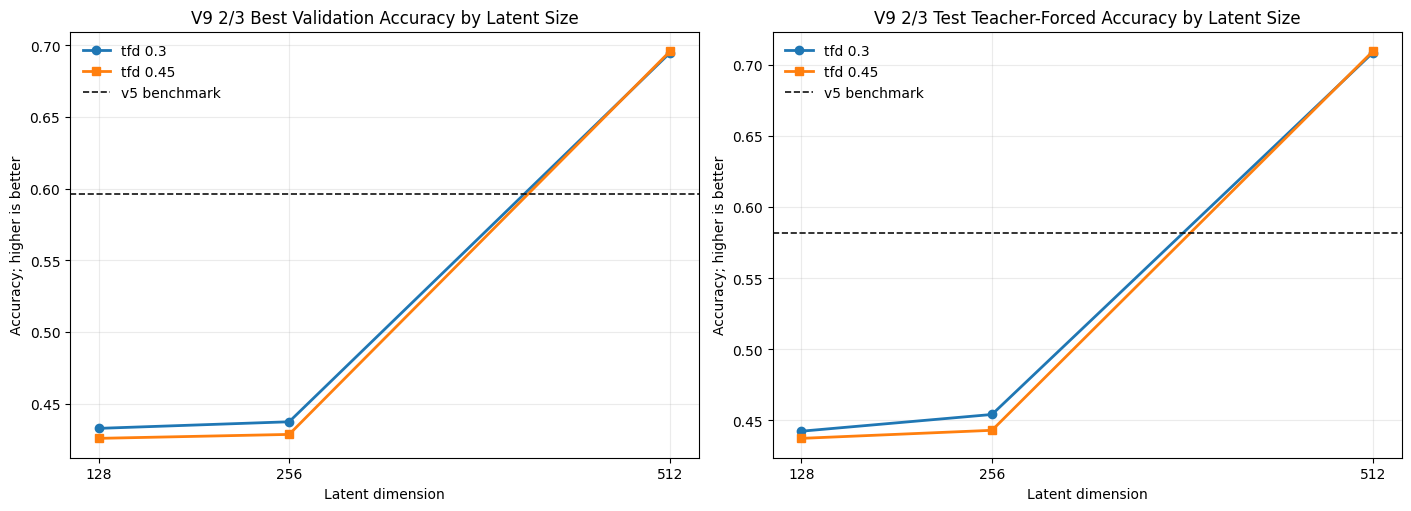

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for tfd, marker in [(0.3, "o"), (0.45, "s")]:
    subset = v9_2of3_runs.loc[v9_2of3_runs["teacher_forcing_dropout"].eq(tfd)].sort_values("latent_dim")
    axes[0].plot(
        subset["latent_dim"],
        subset["best_val_accuracy"],
        marker=marker,
        linewidth=2,
        label=f"tfd {tfd:g}",
    )
    axes[1].plot(
        subset["latent_dim"],
        subset["test_tf_accuracy"],
        marker=marker,
        linewidth=2,
        label=f"tfd {tfd:g}",
    )

axes[0].axhline(benchmark["best_val_accuracy"], color="#111111", linestyle="--", linewidth=1.2, label="v5 benchmark")
axes[1].axhline(benchmark["test_tf_accuracy"], color="#111111", linestyle="--", linewidth=1.2, label="v5 benchmark")
axes[0].set_title("V9 2/3 Best Validation Accuracy by Latent Size")
axes[1].set_title("V9 2/3 Test Teacher-Forced Accuracy by Latent Size")
for ax in axes:
    ax.set_xlabel("Latent dimension")
    ax.set_ylabel("Accuracy; higher is better")
    ax.set_xticks(sorted(v9_2of3_runs["latent_dim"].unique()))
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.show()


### V9 2/3 Accuracy Curve Takeaway

The accuracy curves mirror the loss curves: latent `512` is the only v9 `2/3` setting that clearly exceeds the v5 benchmark. Latent `128` and `256` improve during training but plateau well below the latent `512` checkpoints.


### V9 2/3 Loss Curve Takeaway

Within the v9 `2/3` split, the latent `512` checkpoints separate clearly from latent `128` and `256`: they reach much lower validation loss and also produce the best test losses. The two latent `512` dropout settings are very close, with `tfd0p3` having the lowest teacher-forced test loss and `tfd0p45` having the best autoregressive accuracy from the earlier comparison.


### V10 2/3 Loss Curve Analysis

The next idea was to see if we could get a better, more stable, checkpoint for a smaller latent vector size of `256` on the `2/3` split. The v10 ran checkpoints on latent vector dimensions `256` and did so on conservative learning rate parameters. Below are the results:

#### V10 Comparison Setup

This section compares the available v10 `2/3` latent256 checkpoint(s) against the v9 `2/3` latent256 runs and the v9 `2/3` latent512 reference runs. The v10 history includes learning-rate and gradient-norm diagnostics, so we can check whether the scheduler actually fired and whether gradient spikes aligned with metric collapse.


In [106]:
def parse_history_metadata(path):
    name = path.name
    version = path.parent.name
    latent_match = re.search(r"latent(\d+)", name)
    tfd_match = re.search(r"tfd(\d+)p(\d+)", name)
    sf_match = re.search(r"sf(\d+)p(\d+)", name)
    return {
        "version": version,
        "run_label": name.removesuffix("_history.json").replace(f"{version}_model_ae_length_2_of_3_solubility_", ""),
        "history_path": str(path.relative_to(PROJECT_ROOT)),
        "latent_dim": int(latent_match.group(1)) if latent_match else None,
        "teacher_forcing_dropout": float(f"{tfd_match.group(1)}.{tfd_match.group(2)}") if tfd_match else None,
        "scheduler_factor_suffix": float(f"{sf_match.group(1)}.{sf_match.group(2)}") if sf_match else None,
    }


def load_history_frame(path):
    with path.open() as f:
        history = json.load(f)
    meta = parse_history_metadata(path)
    hp = history.get("hyperparameters", {})
    epochs = pd.DataFrame(history.get("epochs", []))
    for key, value in meta.items():
        epochs[key] = value
    epochs["learning_rate_config"] = hp.get("learning_rate")
    epochs["lr_patience_config"] = hp.get("lr_patience")
    epochs["scheduler_factor_config"] = hp.get("scheduler_factor")
    return history, meta, epochs


def summarize_history(path):
    history, meta, epochs = load_history_frame(path)
    hp = history.get("hyperparameters", {})
    best_loss = epochs.loc[epochs["val_loss"].idxmin()]
    best_acc = epochs.loc[epochs["val_accuracy"].idxmax()]
    final = epochs.iloc[-1]
    test = history.get("test", {})
    return {
        **meta,
        "epochs": len(epochs),
        "learning_rate": hp.get("learning_rate"),
        "lr_patience": hp.get("lr_patience"),
        "scheduler_factor": hp.get("scheduler_factor"),
        "best_val_loss": best_loss["val_loss"],
        "best_val_loss_epoch": int(best_loss["epoch"]),
        "best_val_accuracy": best_acc["val_accuracy"],
        "best_val_accuracy_epoch": int(best_acc["epoch"]),
        "final_train_loss": final["train_loss"],
        "final_val_loss": final["val_loss"],
        "final_train_accuracy": final["train_accuracy"],
        "final_val_accuracy": final["val_accuracy"],
        "final_loss_gap": final["val_loss"] - final["train_loss"],
        "test_tf_loss": test.get("teacher_forced", {}).get("loss"),
        "test_tf_accuracy": test.get("teacher_forced", {}).get("accuracy"),
        "test_ar_loss": test.get("autoregressive", {}).get("loss"),
        "test_ar_accuracy": test.get("autoregressive", {}).get("accuracy"),
    }

v10_paths = sorted((RESULTS_ROOT / "v10").glob("*length_2_of_3*latent256*_history.json"))
v9_reference_paths = sorted((RESULTS_ROOT / "v9").glob("*length_2_of_3*latent256*_history.json"))
v9_reference_paths += sorted((RESULTS_ROOT / "v9").glob("*length_2_of_3*latent512*_history.json"))
comparison_paths = v10_paths + v9_reference_paths

print(f"Found {len(v10_paths)} v10 history file(s):")
for path in v10_paths:
    print(" -", path.relative_to(PROJECT_ROOT))

v10_histories = {}
comparison_epoch_df = []
for path in comparison_paths:
    history, meta, epochs = load_history_frame(path)
    v10_histories[meta["run_label"]] = history
    comparison_epoch_df.append(epochs)

comparison_epoch_df = pd.concat(comparison_epoch_df, ignore_index=True)
v10_comparison_summary = pd.DataFrame([summarize_history(path) for path in comparison_paths])
v10_comparison_summary = v10_comparison_summary.sort_values(["version", "latent_dim", "teacher_forcing_dropout"]).reset_index(drop=True)
v10_comparison_summary


Found 1 v10 history file(s):
 - Code/results/autoencoder/solubility/v10/v10_model_ae_length_2_of_3_solubility_latent256_tfd0p3_sf0p5_history.json


,version,run_label,history_path,latent_dim,teacher_forcing_dropout,scheduler_factor_suffix,epochs,learning_rate,lr_patience,scheduler_factor,best_val_loss,best_val_loss_epoch,best_val_accuracy,best_val_accuracy_epoch,final_train_loss,final_val_loss,final_train_accuracy,final_val_accuracy,final_loss_gap,test_tf_loss,test_tf_accuracy,test_ar_loss,test_ar_accuracy
0,v10,latent256_tfd0p3_sf0p5,Code/results/autoencoder/solubility/v10/v10_mo...,256,0.30,0.5,100,0.0003,5,0.5,0.921966,100,0.638502,100,0.851510,0.921966,0.658972,0.638502,0.070456,0.900727,0.656678,3.836204,0.281173
1,v9,latent256_tfd0p3,Code/results/autoencoder/solubility/v9/v9_mode...,256,0.30,NaN,57,0.0010,3,NaN,1.500889,47,0.437520,47,1.664324,1.646785,0.398327,0.403476,-0.017540,1.492183,0.454164,3.427526,0.174671
2,v9,latent256_tfd0p45,Code/results/autoencoder/solubility/v9/v9_mode...,256,0.45,NaN,59,0.0010,3,NaN,1.548221,49,0.428708,49,1.616255,1.605877,0.411042,0.415918,-0.010378,1.526470,0.443019,3.211277,0.177889
3,v9,latent512_tfd0p3,Code/results/autoencoder/solubility/v9/v9_mode...,512,0.30,NaN,100,0.0010,3,NaN,0.753443,97,0.694954,99,0.715840,0.755032,0.704981,0.692756,0.039192,0.735418,0.709003,3.215062,0.364371
4,v9,latent512_tfd0p45,Code/results/autoencoder/solubility/v9/v9_mode...,512,0.45,NaN,100,0.0010,3,NaN,0.753699,100,0.696039,100,0.707730,0.753699,0.709959,0.696039,0.045969,0.736249,0.710039,3.184764,0.369638


#### Summary Table

The table below compares v10 against the matching v9 latent256 baselines and the v9 latent512 references. The key comparison is v10 latent256 `tfd0p3` versus v9 latent256 `tfd0p3`, because that isolates the same latent size and teacher-forcing dropout while changing the optimizer schedule.


In [107]:
summary_cols = [
    "version",
    "run_label",
    "epochs",
    "latent_dim",
    "teacher_forcing_dropout",
    "learning_rate",
    "lr_patience",
    "scheduler_factor",
    "best_val_loss",
    "best_val_loss_epoch",
    "best_val_accuracy",
    "best_val_accuracy_epoch",
    "test_tf_loss",
    "test_tf_accuracy",
    "test_ar_loss",
    "test_ar_accuracy",
]

v10_comparison_summary[summary_cols]


,version,run_label,epochs,latent_dim,teacher_forcing_dropout,learning_rate,lr_patience,scheduler_factor,best_val_loss,best_val_loss_epoch,best_val_accuracy,best_val_accuracy_epoch,test_tf_loss,test_tf_accuracy,test_ar_loss,test_ar_accuracy
0,v10,latent256_tfd0p3_sf0p5,100,256,0.30,0.0003,5,0.5,0.921966,100,0.638502,100,0.900727,0.656678,3.836204,0.281173
1,v9,latent256_tfd0p3,57,256,0.30,0.0010,3,NaN,1.500889,47,0.437520,47,1.492183,0.454164,3.427526,0.174671
2,v9,latent256_tfd0p45,59,256,0.45,0.0010,3,NaN,1.548221,49,0.428708,49,1.526470,0.443019,3.211277,0.177889
3,v9,latent512_tfd0p3,100,512,0.30,0.0010,3,NaN,0.753443,97,0.694954,99,0.735418,0.709003,3.215062,0.364371
4,v9,latent512_tfd0p45,100,512,0.45,0.0010,3,NaN,0.753699,100,0.696039,100,0.736249,0.710039,3.184764,0.369638


In [108]:
baseline = v10_comparison_summary.loc[
    (v10_comparison_summary["version"].eq("v9"))
    & (v10_comparison_summary["latent_dim"].eq(256))
    & (v10_comparison_summary["teacher_forcing_dropout"].eq(0.3))
].iloc[0]

v10_completed = v10_comparison_summary.loc[v10_comparison_summary["version"].eq("v10")].copy()
for metric in ["best_val_loss", "best_val_accuracy", "test_tf_loss", "test_tf_accuracy", "test_ar_loss", "test_ar_accuracy"]:
    v10_completed[f"delta_vs_v9_256_tfd0p3_{metric}"] = v10_completed[metric] - baseline[metric]

v10_completed[[
    "run_label",
    "best_val_loss",
    "delta_vs_v9_256_tfd0p3_best_val_loss",
    "best_val_accuracy",
    "delta_vs_v9_256_tfd0p3_best_val_accuracy",
    "test_tf_loss",
    "delta_vs_v9_256_tfd0p3_test_tf_loss",
    "test_tf_accuracy",
    "delta_vs_v9_256_tfd0p3_test_tf_accuracy",
    "test_ar_accuracy",
    "delta_vs_v9_256_tfd0p3_test_ar_accuracy",
]]


,run_label,best_val_loss,delta_vs_v9_256_tfd0p3_best_val_loss,best_val_accuracy,delta_vs_v9_256_tfd0p3_best_val_accuracy,test_tf_loss,delta_vs_v9_256_tfd0p3_test_tf_loss,test_tf_accuracy,delta_vs_v9_256_tfd0p3_test_tf_accuracy,test_ar_accuracy,delta_vs_v9_256_tfd0p3_test_ar_accuracy
0,latent256_tfd0p3_sf0p5,0.921966,-0.578923,0.638502,0.200982,0.900727,-0.591456,0.656678,0.202513,0.281173,0.106502


#### Training Curves

These plots show why v10 is different: the v10 latent256 run avoids the epoch-50 collapse seen in v9 latent256 and continues improving through epoch 100. The v9 latent512 lines remain the stronger upper reference, but v10 greatly narrows the gap.


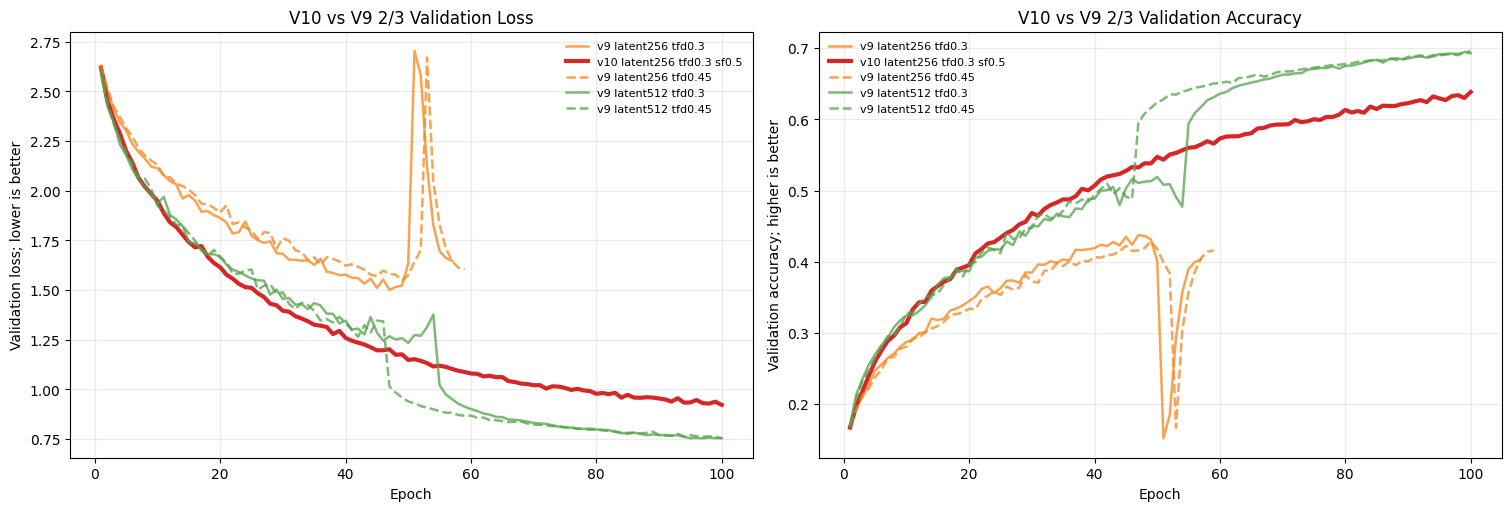

In [109]:
plot_runs = v10_comparison_summary.copy()
plot_runs["plot_label"] = plot_runs.apply(
    lambda row: f"{row['version']} latent{int(row['latent_dim'])} tfd{row['teacher_forcing_dropout']:g}"
    + (f" sf{row['scheduler_factor']:g}" if pd.notna(row["scheduler_factor"]) else ""),
    axis=1,
)
label_map = dict(zip(plot_runs["run_label"], plot_runs["plot_label"]))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for run_label, data in comparison_epoch_df.groupby("run_label"):
    meta = plot_runs.loc[plot_runs["run_label"].eq(run_label)].iloc[0]
    is_v10 = meta["version"] == "v10"
    is_512 = meta["latent_dim"] == 512
    color = "#d62728" if is_v10 else ("#54a24b" if is_512 else "#f58518")
    linestyle = "-" if meta["teacher_forcing_dropout"] == 0.3 else "--"
    linewidth = 3.0 if is_v10 else 1.8
    alpha = 1.0 if is_v10 else 0.75
    label = label_map[run_label]

    axes[0].plot(data["epoch"], data["val_loss"], color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=label)
    axes[1].plot(data["epoch"], data["val_accuracy"], color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=label)

axes[0].set_title("V10 vs V9 2/3 Validation Loss")
axes[0].set_ylabel("Validation loss; lower is better")
axes[1].set_title("V10 vs V9 2/3 Validation Accuracy")
axes[1].set_ylabel("Validation accuracy; higher is better")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
plt.show()


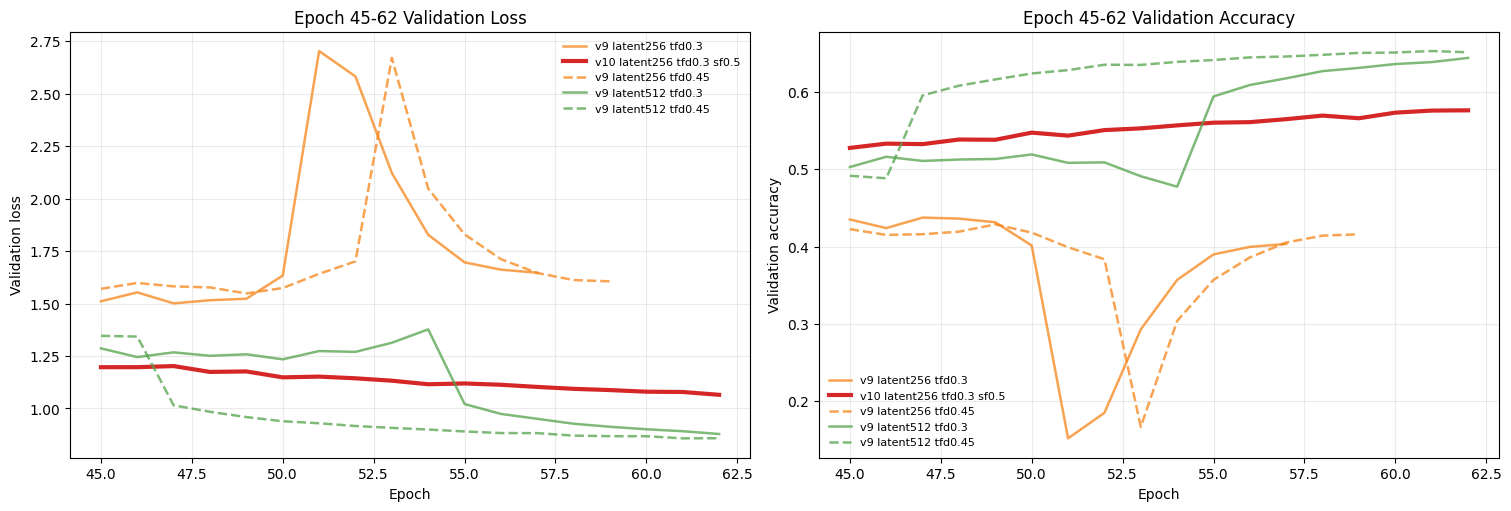

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
window = comparison_epoch_df.loc[comparison_epoch_df["epoch"].between(45, 62)].copy()
for run_label, data in window.groupby("run_label"):
    meta = plot_runs.loc[plot_runs["run_label"].eq(run_label)].iloc[0]
    is_v10 = meta["version"] == "v10"
    is_512 = meta["latent_dim"] == 512
    color = "#d62728" if is_v10 else ("#54a24b" if is_512 else "#f58518")
    linestyle = "-" if meta["teacher_forcing_dropout"] == 0.3 else "--"
    linewidth = 3.0 if is_v10 else 1.8
    alpha = 1.0 if is_v10 else 0.75
    label = label_map[run_label]
    axes[0].plot(data["epoch"], data["val_loss"], color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=label)
    axes[1].plot(data["epoch"], data["val_accuracy"], color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=label)

axes[0].set_title("Epoch 45-62 Validation Loss")
axes[0].set_ylabel("Validation loss")
axes[1].set_title("Epoch 45-62 Validation Accuracy")
axes[1].set_ylabel("Validation accuracy")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
plt.show()


#### Test and Best-Validation Metrics

These bar charts summarize the practical tradeoff. v10 latent256 beats the old v9 latent256 runs by a large margin and beats v5 on teacher-forced metrics, but v9 latent512 still has the best overall reconstruction quality.


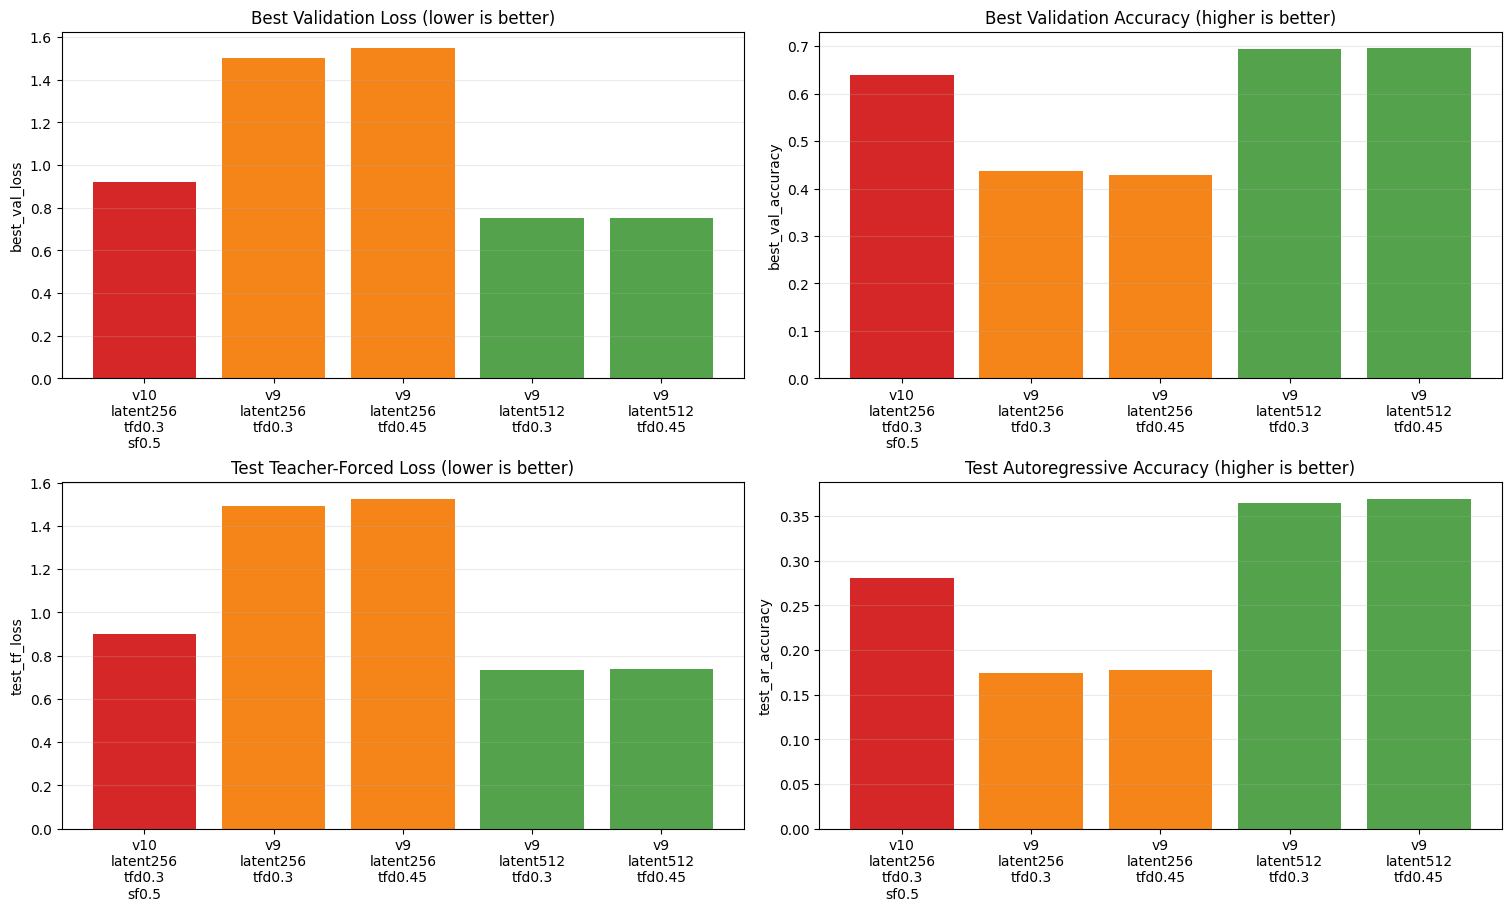

In [111]:
bar_df = v10_comparison_summary.copy()
bar_df["plot_label"] = bar_df.apply(
    lambda row: f"{row['version']}\nlatent{int(row['latent_dim'])}\ntfd{row['teacher_forcing_dropout']:g}"
    + (f"\nsf{row['scheduler_factor']:g}" if pd.notna(row["scheduler_factor"]) else ""),
    axis=1,
)
bar_df = bar_df.sort_values(["latent_dim", "version", "teacher_forcing_dropout"])

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
metrics = [
    ("best_val_loss", "Best Validation Loss", "lower"),
    ("best_val_accuracy", "Best Validation Accuracy", "higher"),
    ("test_tf_loss", "Test Teacher-Forced Loss", "lower"),
    ("test_ar_accuracy", "Test Autoregressive Accuracy", "higher"),
]
colors = ["#d62728" if version == "v10" else ("#54a24b" if latent == 512 else "#f58518") for version, latent in zip(bar_df["version"], bar_df["latent_dim"])]

for ax, (metric, title, direction) in zip(axes.ravel(), metrics):
    ax.bar(bar_df["plot_label"], bar_df[metric], color=colors)
    ax.set_title(f"{title} ({direction} is better)")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", labelrotation=0)
    ax.grid(axis="y", alpha=0.25)
plt.show()


#### V10 LR and Gradient Diagnostics

The v10 run logged learning rate and pre-clip gradient norms. The scheduler did not reduce LR in the completed v10 run, so the improvement is mainly evidence that the lower starting LR avoided the v9 latent256 instability rather than evidence that a later scheduler rescue fixed it.


In [112]:
v10_epoch_df = comparison_epoch_df.loc[comparison_epoch_df["version"].eq("v10")].copy()
if v10_epoch_df.empty:
    print("No v10 epochs available yet.")
else:
    diagnostic_cols = [
        "run_label",
        "epoch",
        "train_loss",
        "val_loss",
        "train_accuracy",
        "val_accuracy",
        "learning_rate",
        "learning_rate_after_scheduler",
        "grad_norm_pre_clip_mean",
        "grad_norm_pre_clip_max",
    ]
    display(v10_epoch_df[diagnostic_cols].tail(20))


,run_label,epoch,train_loss,val_loss,train_accuracy,val_accuracy,learning_rate,learning_rate_after_scheduler,grad_norm_pre_clip_mean,grad_norm_pre_clip_max
80,latent256_tfd0p3_sf0p5,81,0.929077,0.981512,0.627776,0.609709,0.0003,0.0003,3.705024,8.928818
81,latent256_tfd0p3_sf0p5,82,0.924636,0.976341,0.629490,0.611713,0.0003,0.0003,3.648243,6.365588
82,latent256_tfd0p3_sf0p5,83,0.919352,0.982707,0.631585,0.609445,0.0003,0.0003,3.659898,7.148612
83,latent256_tfd0p3_sf0p5,84,0.914283,0.958242,0.633825,0.618070,0.0003,0.0003,3.684451,7.008089
84,latent256_tfd0p3_sf0p5,85,0.910018,0.972553,0.635358,0.614608,0.0003,0.0003,3.714662,6.599734
85,latent256_tfd0p3_sf0p5,86,0.906032,0.958784,0.637002,0.619290,0.0003,0.0003,3.669775,5.972553
86,latent256_tfd0p3_sf0p5,87,0.901149,0.957628,0.638887,0.618956,0.0003,0.0003,3.742170,9.652463
87,latent256_tfd0p3_sf0p5,88,0.897124,0.960513,0.640531,0.618960,0.0003,0.0003,3.710791,6.391955
88,latent256_tfd0p3_sf0p5,89,0.893576,0.958664,0.641988,0.621610,0.0003,0.0003,3.662680,6.698094
89,latent256_tfd0p3_sf0p5,90,0.889177,0.954132,0.643889,0.622669,0.0003,0.0003,3.703027,5.942134


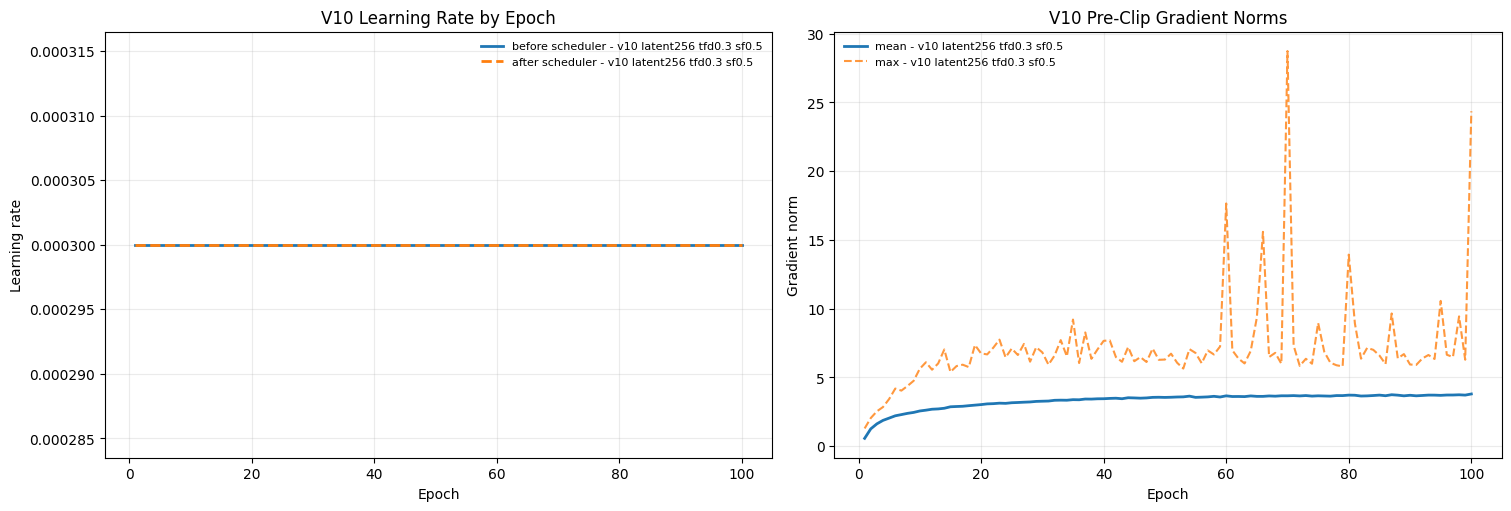

In [113]:
if not v10_epoch_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    for run_label, data in v10_epoch_df.groupby("run_label"):
        label = label_map.get(run_label, run_label)
        axes[0].plot(data["epoch"], data["learning_rate"], label=f"before scheduler - {label}", linewidth=2)
        axes[0].plot(data["epoch"], data["learning_rate_after_scheduler"], linestyle="--", label=f"after scheduler - {label}", linewidth=2)
        axes[1].plot(data["epoch"], data["grad_norm_pre_clip_mean"], label=f"mean - {label}", linewidth=2)
        axes[1].plot(data["epoch"], data["grad_norm_pre_clip_max"], linestyle="--", alpha=0.8, label=f"max - {label}", linewidth=1.5)

    axes[0].set_title("V10 Learning Rate by Epoch")
    axes[0].set_ylabel("Learning rate")
    axes[1].set_title("V10 Pre-Clip Gradient Norms")
    axes[1].set_ylabel("Gradient norm")
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
    plt.show()


#### V10 Takeaway

The available v10 result is a strong positive result for latent256. Compared with the matching v9 latent256 `tfd0p3` run, v10 improves best validation loss from `1.5009` to `0.9220`, best validation accuracy from `0.4375` to `0.6385`, test teacher-forced loss from `1.4922` to `0.9007`, and test autoregressive accuracy from `0.1747` to `0.2812`.

The important diagnostic is that the v10 learning rate stayed at `3e-4` for the whole run. That means the improvement was not caused by the scheduler rescuing the run after collapse. Instead, the lower initial learning rate appears to have prevented the latent256 instability seen in v9. Latent512 still performs better overall, but latent256 is now viable enough to justify additional tuning after the second v10 dropout run completes.
